# Day 12 — Forecast Uncertainty ve Dashboard Validation

## Amaç

Bu çalışmada final forecasting pipeline tarafından üretilen nokta tahminlerinin
yanında tahmin belirsizliğini de gösterebilmek amaçlanmaktadır.

Mevcut sistem ChatGPT, Gemini ve Claude için gelecek 4 haftaya ait tek bir
tahmin değeri üretmektedir.

Ancak gerçek zaman serilerinde gelecek değerlerin tam olarak bu nokta
tahminlerine eşit olması beklenmez.

Bu nedenle geçmiş Time-Series Cross-Validation tahmin hatalarından yararlanarak
ampirik prediction interval yaklaşımı geliştirilecektir.

Amaç, dashboard üzerinde kullanıcıya yalnızca:

"Beklenen değer nedir?"

sorusunun cevabını değil,

"Bu tahminin çevresinde ne kadar belirsizlik bulunmaktadır?"

sorusuna ilişkin bir gösterge de sunmaktır.

## 1. Prediction Interval Mantığı

Forecasting modeli gelecekteki değer için bir nokta tahmini üretir.

Örneğin:

- Gerçek değer: `72`
- Model tahmini: `69`

ise modelin tahmin hatası:

`residual = actual - prediction`

formülüyle hesaplanır.

Bu örnekte:

`72 - 69 = +3`

olur.

Pozitif residual, modelin gerçek değerin altında tahmin yaptığını gösterir.

Başka bir örnekte:

- Gerçek değer: `65`
- Model tahmini: `68`

ise:

`65 - 68 = -3`

olur.

Negatif residual ise modelin gerçek değerin üzerinde tahmin yaptığını gösterir.

Bu projede geçmiş Time-Series Cross-Validation tahminlerinden residual
değerleri toplanacaktır.

Daha sonra bu geçmiş hata dağılımı kullanılarak gelecekteki nokta tahminlerinin
çevresinde ampirik bir prediction interval oluşturulacaktır.

Örneğin merkezi %80'lik bir prediction interval için residual dağılımının:

- %10 quantile değeri alt sınırda
- %90 quantile değeri üst sınırda

kullanılabilir.

Formül:

`Lower Bound = Point Forecast + Residual Q10`

`Upper Bound = Point Forecast + Residual Q90`

şeklindedir.

Bu yaklaşım teorik olarak geleceğin kesin olarak bu aralıkta kalacağını garanti
etmez. Geçmiş cross-validation hatalarına dayalı ampirik bir belirsizlik
göstergesidir.

## Neden MAE Yerine Residual Dağılımını Kullanıyoruz?

Forecasting modellerini değerlendirirken MAE gibi hata metrikleri oldukça
faydalıdır. Ancak MAE ile residual aynı şeyi ifade etmez ve prediction interval
oluştururken farklı amaçlara hizmet ederler.

### MAE Nedir?

MAE, yani Mean Absolute Error, modelin tahminlerinin gerçek değerlerden ortalama
olarak ne kadar uzaklaştığını ölçer.

Formül:

`MAE = mean(|actual - prediction|)`

Örneğin tahmin hataları:

`+2, -4, +3, -1`

olsun.

Absolute error değerleri:

`2, 4, 3, 1`

olur.

Bunların ortalaması:

`MAE = 2.5`

olarak hesaplanır.

Bu sonuç bize modelin geçmiş tahminlerinde ortalama olarak yaklaşık 2.5 puanlık
bir hata yaptığını söyler.

Ancak MAE yalnızca hataların büyüklüğünü özetleyen tek bir sayıdır.

Hataların:

- hangi yönde gerçekleştiğini,
- ne kadar yayıldığını,
- dağılımın simetrik olup olmadığını,
- bazı dönemlerde çok daha büyük hatalar oluşup oluşmadığını

göstermez.


### Neden `forecast ± MAE` Kullanmak Yeterli Değildir?

Örneğin modelin gelecek hafta için tahmini:

`70`

ve geçmiş MAE değeri:

`4`

olsun.

Doğrudan:

`70 ± 4`

yaparsak:

`66 - 74`

aralığını elde ederiz.

Ancak bu aralık gerçek bir prediction interval değildir.

Çünkü MAE bize geçmiş tahmin hatalarının yalnızca ortalama mutlak büyüklüğünü
verir.

Örneğin iki farklı modelin MAE değeri aynı olabilir:

Model A residual'ları:

`-4, -4, +4, +4`

Model B residual'ları:

`-1, -1, -1, +13`

Bu iki hata yapısının davranışı oldukça farklıdır.

İkinci model zaman zaman çok büyük hata yapmasına rağmen yalnızca ortalama hata
değerine bakıldığında bu fark yeterince görünmeyebilir.

Bu nedenle tahmin belirsizliğini oluştururken yalnızca tek bir MAE değerine
bakmak geçmiş hata yapısındaki önemli bilgilerin kaybolmasına neden olur.


### Residual Nedir?

Residual, gerçek değer ile model tahmini arasındaki farktır.

Formül:

`residual = actual - prediction`

Örneğin:

- Gerçek değer: `72`
- Tahmin: `69`

ise:

`residual = 72 - 69 = +3`

olur.

Pozitif residual, modelin gerçek değerin altında tahmin yaptığını gösterir.

Başka bir örnekte:

- Gerçek değer: `65`
- Tahmin: `68`

ise:

`residual = 65 - 68 = -3`

olur.

Negatif residual ise modelin gerçek değerin üzerinde tahmin yaptığını gösterir.


### Residual Neden Daha Fazla Bilgi Taşır?

Residual değerleri işaretlerini korur.

Bu nedenle geçmişte modelin:

- ne kadar hata yaptığı,
- hangi yönde hata yaptığı,
- hataların ne kadar yayıldığı,
- büyük hataların ne sıklıkla oluştuğu

hakkında bilgi sağlar.

Örneğin residual dağılımımız:

`-6, -3, -2, -1, 0, +1, +2, +4, +7`

şeklindeyse modelin geçmiş tahmin davranışını MAE'den çok daha ayrıntılı şekilde
görebiliriz.

Bu dağılım üzerinden quantile değerleri hesaplanabilir.

Örneğin merkezi %80'lik bir ampirik prediction interval oluşturmak istersek:

- Alt sınır için residual dağılımının `%10 quantile`
- Üst sınır için residual dağılımının `%90 quantile`

değerlerini kullanabiliriz.

Daha sonra:

`Lower Bound = Point Forecast + Residual Q10`

`Upper Bound = Point Forecast + Residual Q90`

şeklinde tahmin aralığı oluşturabiliriz.


### Neden Residual'ları Cross-Validation'dan Alıyoruz?

Final model tüm veri üzerinde eğitildiğinde training verisi üzerindeki hatalar
gerçek gelecek performansını olduğundan daha iyi gösterebilir.

Bu nedenle residual'ları modelin eğitim sırasında zaten gördüğü veriden almak
yerine Time-Series Cross-Validation sırasında oluşturulan tahminlerden elde
etmek daha anlamlıdır.

Cross-validation sırasında her test dönemi model için o anda görülmemiş gelecek
veriyi temsil eder.

Bu nedenle:

`CV residual = gerçek test değeri - test dönemi tahmini`

şeklinde elde edilen residual'lar modelin gerçek forecasting hatasına daha yakın
bir hata dağılımı oluşturur.


### MAE'yi Artık Kullanmayacak mıyız?

Hayır.

MAE hâlâ çok önemli bir metriktir.

Bu projede MAE:

- modelleri karşılaştırmak,
- hangi modelin daha başarılı olduğunu değerlendirmek,
- ortalama tahmin hatasını özetlemek

için kullanılmaya devam eder.

Residual dağılımı ise farklı bir amaç taşır:

- tahmin belirsizliğini incelemek,
- prediction interval oluşturmak,
- modelin hata yönünü ve dağılımını analiz etmek

için kullanılır.

Kısaca:

`MAE → Model ortalama olarak ne kadar hata yapıyor?`

`Residual Distribution → Model geçmişte nasıl ve hangi yönde hata yapıyor?`

Bu nedenle final prediction interval yaklaşımında yalnızca MAE değerini
kullanmak yerine cross-validation residual dağılımından yararlanılacaktır.

Tabii, buradaki mantık şu:

Diyelim ki cross-validation’dan elimizde **100 tane residual** var. Bunları küçükten büyüğe sıralıyoruz.

```text
-12, -9, -7, -6, ... 0 ... +3, +5, +8, +11
```

Şimdi biz diyoruz ki:

> “Geçmiş hataların ortadaki %80’lik kısmı hangi aralıkta kalmış?”

Bunu bulmak için en küçük taraftaki %10’u ve en büyük taraftaki %10’u dışarıda bırakıyoruz.

Çünkü:

```text
%10 + %80 + %10 = %100
```

Yani kabaca:

```text
en düşük %10       ortadaki %80       en yüksek %10
─────────────|─────────────────────|─────────────
            Q10                   Q90
```

Buradaki **Q10 (10. quantile)** şu anlama geliyor:

> Residual değerlerinin yaklaşık %10’u bu değerin altında, %90’ı üstünde.

**Q90 (90. quantile)** ise:

> Residual değerlerinin yaklaşık %90’ı bu değerin altında, %10’u üstünde.

Mesela bizim CV residual’larımızdan şöyle bir sonuç çıktığını düşün:

```text
Q10 = -4
Q90 = +6
```

Bunun anlamı:

> Geçmiş cross-validation hatalarının yaklaşık ortadaki %80’i `-4` ile `+6` arasında kalmış.

Şimdi final model gelecek hafta için:

```text
Forecast = 70
```

tahmin ettiyse, bu geçmiş hata davranışını forecast’a ekliyoruz:

```text
Alt sınır = 70 + (-4) = 66
Üst sınır = 70 + 6    = 76
```

Dolayısıyla dashboard’da:

```text
Nokta tahmini: 70
Ampirik %80 prediction interval: 66 – 76
```

diyebiliriz.

### Peki neden %80 için Q10 ve Q90?

Çünkü iki taraftan toplam %20’yi dışarıda bırakmamız gerekiyor.

Ortada `%80` bırakmak istiyoruz:

```text
100% - 80% = 20%
```

Bu `%20`yi iki kuyruğa eşit dağıtıyoruz:

```text
Alt tarafta  %10
Üst tarafta %10
```

O yüzden sınırlar:

```text
10. quantile → alt sınır
90. quantile → üst sınır
```

oluyor.

Aynı mantıkla mesela **%90'lık** merkezi aralık isteseydik:

```text
100 - 90 = 10
10 / 2 = 5
```

dolayısıyla:

```text
Q5  → alt sınır
Q95 → üst sınır
```

kullanırdık.

Bir de önemli nokta: burada `%80` demek **“gelecek değerin kesin %80 ihtimalle burada olacağını matematiksel olarak kanıtladık”** demek değil. Bizim yaklaşımımız ampirik; yani daha temkinli ifade şu:

> “Geçmiş cross-validation hatalarının merkezi %80’lik kısmına dayanarak oluşturulan tahmin aralığı.”

Yani tamamen modelimizin **geçmişte gerçekten yaptığı hatalara** bakıyoruz.


Prediction interval yüzdesi henüz final olarak belirlenmemiştir.

İlk aşamada merkezi %80'lik ampirik aralık (`Q10-Q90`) incelenecek,
gerekirse %90'lık aralık (`Q5-Q95`) ile karşılaştırılacaktır.

Final aralık seviyesi, cross-validation residual dağılımının davranışı
incelendikten sonra seçilecektir.

In [1]:
# ---------------------------------------------------------
# DAY 12 - Başlangıç
# ---------------------------------------------------------

# Path:
# Dosya ve klasör yollarıyla daha güvenli çalışmamızı sağlar.
#
# Örneğin:
# Path("data") / "processed"
#
# yazdığımızda işletim sistemine uygun bir dosya yolu oluşturur.
from pathlib import Path

# NumPy:
# Sayısal hesaplamalarda kullanacağız.
#
# İleride özellikle:
# - quantile hesaplama
# - residual analizi
# gibi işlemlerde gerekli olacak.
import numpy as np

# Pandas:
# Zaman serisi verisini ve cross-validation sonuçlarını
# DataFrame / Series olarak yönetmek için kullanacağız.
import pandas as pd


# ---------------------------------------------------------
# Çalışma klasörünü kontrol ediyoruz
# ---------------------------------------------------------

# Path.cwd()
# "current working directory" yani Python'un şu anda
# hangi klasörü ana klasör olarak gördüğünü verir.
#
# Bunu kontrol etmemizin nedeni:
# birazdan data/, models/ ve reports/ dosyalarını okuyacağız.
current_directory = Path.cwd()

print("Current working directory:")
print(current_directory)

Current working directory:
/Users/nihalapple/Desktop/trend-forecast-project/notebooks


In [2]:
# ---------------------------------------------------------
# Proje ana klasörünü belirliyoruz
# ---------------------------------------------------------

# current_directory şu anda:
#
# /Users/nihalapple/Desktop/trend-forecast-project/notebooks
#
# .parent:
# Bir dosya veya klasör yolunun bir üst klasörünü verir.
#
# Yani:
#
# notebooks.parent
#       ↓
# trend-forecast-project
PROJECT_ROOT = current_directory.parent


# ---------------------------------------------------------
# Güncel veri dosyasının yolunu oluşturuyoruz
# ---------------------------------------------------------

# / operatörü Path nesnelerinde klasörleri ve dosya isimlerini
# birbirine eklemek için kullanılabilir.
#
# Sonuç:
#
# trend-forecast-project/
#     data/
#         processed/
#             google_trends_ai_3y_updated_2026-08-09.csv
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "google_trends_ai_3y_updated_2026-08-09.csv"
)


# Oluşturduğumuz yolları kontrol ediyoruz.
print("Project root:")
print(PROJECT_ROOT)

print("\nData path:")
print(DATA_PATH)

# .exists():
# Belirttiğimiz dosyanın gerçekten bilgisayarda bulunup
# bulunmadığını True / False olarak döndürür.
#
# True  → dosya bulundu
# False → yol veya dosya isminde problem var
print("\nData file exists:")
print(DATA_PATH.exists())

Project root:
/Users/nihalapple/Desktop/trend-forecast-project

Data path:
/Users/nihalapple/Desktop/trend-forecast-project/data/processed/google_trends_ai_3y_updated_2026-08-09.csv

Data file exists:
True


In [4]:
# ---------------------------------------------------------
# Güncel Google Trends verisini yüklüyoruz
# ---------------------------------------------------------

# pd.read_csv():
# CSV dosyasını pandas DataFrame olarak okur.
#
# parse_dates=["date"]:
# "date" kolonunun normal metin olarak değil,
# pandas tarih tipi (datetime) olarak okunmasını sağlar.
#
# index_col="date":
# "date" kolonunu normal bir DataFrame kolonu yerine
# zaman serisinin index'i olarak kullanır.
data = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"],
    index_col="date",
)


# ---------------------------------------------------------
# Veriyi kontrol ediyoruz
# ---------------------------------------------------------

print("Shape:")
print(data.shape)

print("\nFirst rows:")
display(data.head())

print("\nLast rows:")
display(data.tail())

Shape:
(159, 3)

First rows:


,chatgpt,gemini,claude
date,,,
2023-07-30,13,1,1
2023-08-06,14,1,1
2023-08-13,14,1,1
2023-08-20,15,1,1
2023-08-27,16,1,1



Last rows:


,chatgpt,gemini,claude
date,,,
2026-07-12,65,37,15
2026-07-19,69,38,16
2026-07-26,66,38,16
2026-08-02,66,40,14
2026-08-09,70,40,15


## 3. Cross-Validation Residual'larının Toplanması

Prediction interval oluşturabilmek için yalnızca her fold'un MAE veya RMSE
değerini bilmek yeterli değildir.

Her test gözlemi için:

- gerçek değer (`Actual`)
- model tahmini (`Prediction`)
- tahmin hatası (`Residual`)

saklanacaktır.

Residual:

`Residual = Actual - Prediction`

şeklinde hesaplanacaktır.

İlk olarak bu yapının mantığını görmek için basit Naive model kullanılacaktır.

Naive model bir sonraki dönemin değerini son gözlenen değer olarak tahmin eder.

Amaç Naive modeli tekrar değerlendirmek değil, cross-validation sırasında
residual değerlerinin nasıl toplandığını anlamaktır.

In [5]:
from sklearn.model_selection import TimeSeriesSplit


# ---------------------------------------------------------
# Örnek zaman serisini seçiyoruz
# ---------------------------------------------------------

# İlk aşamada Gemini serisini kullanıyoruz.
#
# Bunun nedeni:
# Gemini'nin final modeli zaten Naive olduğu için
# burada oluşturduğumuz residual yapısını daha sonra
# gerçek prediction interval hesabında da kullanabileceğiz.
gemini_series = data["gemini"].astype(float)


# ---------------------------------------------------------
# Time-Series Cross-Validation yapısını oluşturuyoruz
# ---------------------------------------------------------

# Önceki model değerlendirmelerimizde:
#
# - 12 fold
# - her fold'da 4 haftalık test dönemi
#
# kullanmıştık.
#
# Aynı evaluation yapısını korumamız önemli.
# Çünkü prediction interval residual'ları ile
# model seçiminde kullandığımız CV yapısı tutarlı olmalı.
tscv = TimeSeriesSplit(
    n_splits=12, # 12 fold
    test_size=4, # her foldda test edilcek (tahmin edilecek) değer sayısı
)


# Her fold'dan oluşturacağımız küçük DataFrame'leri
# bu listenin içine koyacağız.
#
# Daha sonra pd.concat() ile hepsini tek tablo haline
# getireceğiz.
residual_frames = []


# ---------------------------------------------------------
# Cross-validation döngüsü
# ---------------------------------------------------------

for fold, (train_index, test_index) in enumerate(
    tscv.split(gemini_series),
    start=1, #fold 1 den başladı
):

    # train_index ve test_index doğrudan tarih değil,
    # serinin satır pozisyonlarını içerir.
    #
    # Bu nedenle .loc değil .iloc kullanmamız gerekiyor.
    #
    # TODO 1:
    # Gemini serisinden train ve test bölümlerini oluştur.
    train_series = gemini_series.iloc[train_index]
    test_series = gemini_series.iloc[test_index]


    # -----------------------------------------------------
    # Naive tahmin
    # -----------------------------------------------------

    # Naive modelin mantığı:
    #
    # Test dönemindeki bütün haftalar için,
    # training döneminin SON gerçek değerini kullan.
    #
    # Örneğin train son değeri 40 ise:
    #
    # prediction = [40, 40, 40, 40]
    #
    # np.repeat(değer, tekrar_sayısı)
    # aynı değeri istediğimiz sayıda tekrar eder.
    naive_predictions = np.repeat(
        train_series.iloc[-1],
        len(test_series),
    )


    # -----------------------------------------------------
    # Residual hesabı
    # -----------------------------------------------------

    # residual = actual - prediction
    #
    # TODO 2:
    # Test serisinin gerçek değerleri ile naive tahminleri
    # kullanarak residual'ları hesapla.
    residuals = test_series-naive_predictions


    # -----------------------------------------------------
    # Fold sonuçlarını tablo haline getiriyoruz
    # -----------------------------------------------------

    # Burada her test gözlemi için şu bilgileri saklayacağız:
    #
    # Fold | Actual | Prediction | Residual
    #
    # TODO 3:
    # Aşağıdaki DataFrame içerisinde eksik olan
    # Actual ve Residual alanlarını tamamla.
    fold_result = pd.DataFrame(
        {
            "Fold": fold,
            "Actual": test_series,
            "Prediction": naive_predictions,
            "Residual": residuals,
        },
        index=test_series.index,
    )


    # Her fold'un tablosunu listeye ekliyoruz.
    residual_frames.append(fold_result)


# ---------------------------------------------------------
# Tüm fold'ları tek tabloda birleştiriyoruz
# ---------------------------------------------------------

# residual_frames şu anda şöyle bir yapı:
#
# [
#     Fold 1 DataFrame,
#     Fold 2 DataFrame,
#     ...
#     Fold 12 DataFrame
# ]
#
# TODO 4:
# pd.concat() kullanarak bütün fold DataFrame'lerini
# tek bir DataFrame haline getir.
gemini_naive_residuals = pd.concat(residual_frames,axis=0)


display(gemini_naive_residuals.head(10))

,Fold,Actual,Prediction,Residual
date,,,,
2025-09-14,1,100.0,63.0,37.0
2025-09-21,1,60.0,63.0,-3.0
2025-09-28,1,45.0,63.0,-18.0
2025-10-05,1,37.0,63.0,-26.0
2025-10-12,2,34.0,37.0,-3.0
2025-10-19,2,32.0,37.0,-5.0
2025-10-26,2,31.0,37.0,-6.0
2025-11-02,2,31.0,37.0,-6.0
2025-11-09,3,32.0,31.0,1.0


In [6]:
# ---------------------------------------------------------
# Residual tablosunun doğru oluştuğunu kontrol ediyoruz
# ---------------------------------------------------------

# 12 fold × her fold'da 4 test gözlemi
# olduğuna göre toplam kaç residual bekliyoruz?
expected_residual_count = 48


print("Residual tablosunun boyutu:")
print(gemini_naive_residuals.shape)


print("\nBeklenen residual sayısı:")
print(expected_residual_count)


# len():
# Bir DataFrame'in kaç satırı olduğunu verir.
#
# TODO:
# Gerçek residual sayısının beklediğimiz sayıya
# eşit olup olmadığını karşılaştır.
print("\nResidual sayısı doğru mu?")
print(
    len(gemini_naive_residuals)==expected_residual_count
)


# Her fold'da gerçekten 4 gözlem bulunuyor mu?
#
# value_counts():
# Bir kolondaki her farklı değerin kaç kez
# tekrar ettiğini sayar.
print("\nHer fold'daki gözlem sayısı:")
print(
    gemini_naive_residuals["Fold"].value_counts().sort_index()
)


# isna():
# Her hücrenin eksik olup olmadığını True/False olarak verir.
#
# İlk .sum():
# Her kolon için kaç eksik değer olduğunu hesaplar.
#
# İkinci .sum():
# Kolonlardaki eksik değer sayılarını da toplar.
#
# Sonucun 0 olmasını bekliyoruz.
print("\nToplam eksik değer:")
print(
    gemini_naive_residuals.isna().sum().sum()
)

Residual tablosunun boyutu:
(48, 4)

Beklenen residual sayısı:
48

Residual sayısı doğru mu?
True

Her fold'daki gözlem sayısı:
Fold
1     4
2     4
3     4
4     4
5     4
6     4
7     4
8     4
9     4
10    4
11    4
12    4
Name: count, dtype: int64

Toplam eksik değer:
0


## 4. Residual Dağılımının İncelenmesi

Cross-validation sonucunda Gemini Naive modeli için 48 adet out-of-sample
residual elde edildi.

Prediction interval oluşturmadan önce residual dağılımının incelenmesi
önemlidir.

Bu aşamada özellikle şu sorulara bakılacaktır:

- Residual'ların merkezi yaklaşık nerede?
- Model sistematik olarak düşük veya yüksek tahmin ediyor mu?
- Hataların yayılımı ne kadar?
- Çok büyük pozitif veya negatif hatalar var mı?
- Merkezi %80 ve %90 ampirik aralıklar ne kadar geniş?

Residual formülü:

`Residual = Actual - Prediction`

olduğu için:

- Pozitif residual → model gerçek değerin altında tahmin yapmıştır.
- Negatif residual → model gerçek değerin üzerinde tahmin yapmıştır.
- Residual'ın 0'a yakın olması → tahmin gerçek değere yakındır.

Residual dağılımının merkezi 0'a yakınsa modelde belirgin bir yukarı veya
aşağı yönlü tahmin yanlılığı olmadığına dair olumlu bir işaret olabilir.

Ancak yalnızca ortalamaya bakmak yeterli değildir. Dağılımın yayılımı ve
uç değerleri de ayrıca incelenmelidir.

In [10]:
# ---------------------------------------------------------
# Gemini Naive residual serisini seçiyoruz
# ---------------------------------------------------------

# DataFrame içerisindeki "Residual" kolonunu ayrı bir
# pandas Series olarak alıyoruz.
#
# Böylece bundan sonraki istatistiksel hesaplamaları
# doğrudan residual değerleri üzerinde yapabiliriz.
gemini_residuals = gemini_naive_residuals["Residual"]


# ---------------------------------------------------------
# Temel residual istatistikleri
# ---------------------------------------------------------

# .describe():
# Sayısal bir Series için otomatik olarak:
#
# - count   → gözlem sayısı
# - mean    → ortalama
# - std     → standart sapma
# - min     → minimum
# - 25%     → 1. çeyrek
# - 50%     → median
# - 75%     → 3. çeyrek
# - max     → maksimum
#
# bilgilerini verir.
print("Residual özet istatistikleri:")
display(gemini_residuals.describe())


# ---------------------------------------------------------
# Ortalama ve median residual
# ---------------------------------------------------------

# Ortalama residual:
# Modelin genel olarak hangi yönde hata yapmaya eğilimli
# olduğunu incelemek için kullanabiliriz.
#
# Pozitif ortalama:
# model genel olarak düşük tahmin ediyor olabilir.
#
# Negatif ortalama:
# model genel olarak yüksek tahmin ediyor olabilir.
mean_residual = gemini_residuals.mean()

# Median:
# Residual'ların ortadaki değeridir.
#
# Uç değerlerden mean kadar güçlü etkilenmediği için
# residual dağılımının merkezini anlamada faydalıdır.
median_residual = gemini_residuals.median()


print("Mean residual:", round(mean_residual, 3))
print("Median residual:", round(median_residual, 3))

display(gemini_residuals)

Residual özet istatistikleri:


count    48.000000
mean      0.083333
std       7.811158
min     -26.000000
25%      -3.000000
50%       0.000000
75%       3.000000
max      37.000000
Name: Residual, dtype: float64

Mean residual: 0.083
Median residual: 0.0


date
2025-09-14    37.0
2025-09-21    -3.0
2025-09-28   -18.0
2025-10-05   -26.0
2025-10-12    -3.0
2025-10-19    -5.0
2025-10-26    -6.0
2025-11-02    -6.0
2025-11-09     1.0
2025-11-16     4.0
2025-11-23     3.0
2025-11-30     2.0
2025-12-07     0.0
2025-12-14     0.0
2025-12-21    -3.0
2025-12-28    -4.0
2026-01-04     5.0
2026-01-11     5.0
2026-01-18     4.0
2026-01-25     5.0
2026-02-01     0.0
2026-02-08    -1.0
2026-02-15    -3.0
2026-02-22     2.0
2026-03-01     2.0
2026-03-08     5.0
2026-03-15     3.0
2026-03-22     6.0
2026-03-29    -2.0
2026-04-05    -3.0
2026-04-12    -1.0
2026-04-19    -1.0
2026-04-26     2.0
2026-05-03     3.0
2026-05-10     3.0
2026-05-17     5.0
2026-05-24    -2.0
2026-05-31    -1.0
2026-06-07     1.0
2026-06-14    -3.0
2026-06-21     0.0
2026-06-28    -1.0
2026-07-05    -4.0
2026-07-12    -6.0
2026-07-19     1.0
2026-07-26     1.0
2026-08-02     3.0
2026-08-09     3.0
Name: Residual, dtype: float64

2023-07-30                                      2026-08-09
│                                                    │
│<----------- ilk 111 hafta ---------------->│<--48 hafta-->│
│                 TRAIN                     │    TEST'ler   │
│                                           │              │
2023                 2024              2025-09        2026

In [8]:
# ---------------------------------------------------------
# %80 ve %90 ampirik residual aralıklarını hesaplıyoruz
# ---------------------------------------------------------

# Series.quantile(q):
# Verinin belirli bir yüzdelik noktasını hesaplar.
#
# Örneğin:
#
# quantile(0.10)
#
# residual'ların yaklaşık %10'unun altında kaldığı
# değeri verir.
#
# Merkezi %80'lik aralık için:
#
# %10 ----------- %80 ----------- %10
#       Q10                  Q90
#
# Merkezi %90'lık aralık için:
#
# %5 ------------- %90 ------------- %5
#       Q05                    Q95


# TODO 1:
# Merkezi %80'lik residual aralığının
# alt ve üst quantile değerlerini hesapla.
q10 = gemini_residuals.quantile(0.10)
q90 = gemini_residuals.quantile(0.90) #Verilerin %90'ı hangi değerin altında veya o değere eşit kalıyor?


# TODO 2:
# Merkezi %90'lık residual aralığın
# alt ve üst quantile değerlerini hesapla.
q05 = gemini_residuals.quantile(0.05)
q95 = gemini_residuals.quantile(0.95)


print("Merkezi %80 residual aralığı:")
print(
    f"Q10 = {q10:.3f}, Q90 = {q90:.3f}"
)

print("\nMerkezi %90 residual aralığı:")
print(
    f"Q05 = {q05:.3f}, Q95 = {q95:.3f}"
)

Merkezi %80 residual aralığı:
Q10 = -5.300, Q90 = 5.000

Merkezi %90 residual aralığı:
Q05 = -6.000, Q95 = 5.000


In [9]:
# ---------------------------------------------------------
# Aralık genişliklerini hesaplıyoruz
# ---------------------------------------------------------

# Bir aralığın genişliği:
#
# üst sınır - alt sınır
#
# Örneğin:
#
# [-4, +6]
#
# için genişlik:
#
# 6 - (-4) = 10
#
# olur.


# TODO 3:
# %80 residual aralığının genişliğini hesapla.
width_80 = q90-q10


# TODO 4:
# %90 residual aralığının genişliğini hesapla.
width_90 = q95-q05


print(
    f"%80 residual aralık genişliği: "
    f"{width_80:.3f}"
)

print(
    f"%90 residual aralık genişliği: "
    f"{width_90:.3f}"
)

%80 residual aralık genişliği: 10.300
%90 residual aralık genişliği: 11.000


### Ampirik Prediction Interval Seviyesinin Seçilmesi

Gemini Naive cross-validation residual'ları kullanılarak merkezi %80 ve
%90 ampirik residual aralıkları karşılaştırıldı.

Sonuçlar:

- Merkezi %80 (`Q10-Q90`) → `[-5.3, +5.0]`
- Merkezi %90 (`Q05-Q95`) → `[-6.0, +5.0]`

Aralık genişlikleri:

- %80 → `10.3`
- %90 → `11.0`

İki aralık arasında yalnızca `0.7` Google Trends puanlık genişlik farkı
oluştu.

Bununla birlikte toplam cross-validation residual sayısı 48'dir.
%5 ve %95 quantile değerleri dağılımın oldukça uç bölgesindeki az sayıda
gözleme dayandığı için örneklem değişimlerinden daha fazla etkilenebilir.

Bu nedenle mevcut veri miktarı için merkezi %80'lik ampirik prediction
interval (`Q10-Q90`) daha stabil ve yorumlanabilir bir başlangıç yaklaşımı
olarak seçildi.

Bu seçim kesin ve değişmez bir optimum olarak değerlendirilmemektedir.
Daha fazla out-of-sample residual biriktikçe interval seviyesi yeniden
değerlendirilebilir.

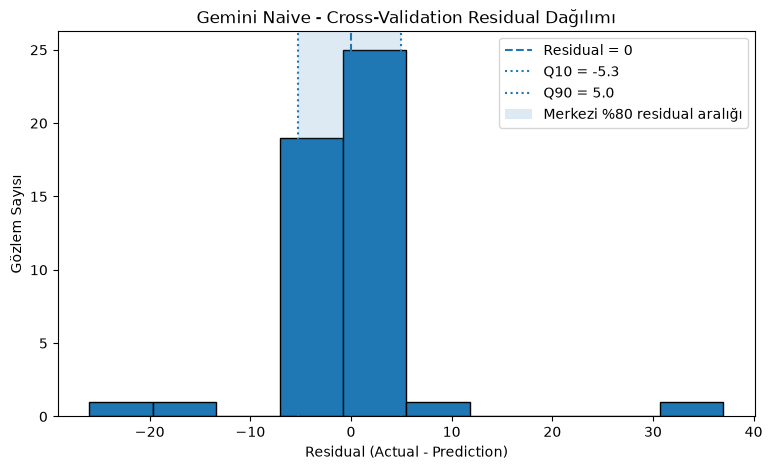

In [15]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Gemini Naive residual dağılımını görselleştiriyoruz
# ---------------------------------------------------------

# Histogram:
# Residual değerlerini belirli aralıklara ayırır ve
# her aralıkta kaç gözlem bulunduğunu gösterir.
#
# bins=10:
# 48 residual için dağılımı gereksiz yere çok fazla
# parçalamadan genel yapıyı görebilmek amacıyla
# 10 aralık kullanıyoruz.
plt.figure(figsize=(9, 5))

plt.hist(
    gemini_residuals,
    bins=10,
    edgecolor="black",
)


# ---------------------------------------------------------
# Residual = 0 referans çizgisi
# ---------------------------------------------------------

# Residual = 0:
# Actual ile Prediction'ın tamamen eşit olduğu noktadır.
#
# Bu çizgi sayesinde residual'ların negatif ve pozitif
# tarafta nasıl dağıldığını daha rahat görebiliriz.
plt.axvline(
    x=0,
    linestyle="--",
    label="Residual = 0",
)


# ---------------------------------------------------------
# %80 ampirik aralığın sınırlarını da gösteriyoruz
# ---------------------------------------------------------

# q10:
# residual dağılımının alt %10 sınırı
#
# q90:
# residual dağılımının üst %10'a geçmeden önceki sınırı
#
# Böylece Q10-Q90 arasında merkezi yaklaşık %80'lik
# residual bölgesini görsel olarak görebileceğiz.
plt.axvline(
    x=q10,
    linestyle=":",
    label=f"Q10 = {q10:.1f}",
)

plt.axvline(
    x=q90,
    linestyle=":",
    label=f"Q90 = {q90:.1f}",
)

# ---------------------------------------------------------
# Merkezi %80 residual bölgesini gösteriyoruz
# ---------------------------------------------------------

# axvspan():
# Grafikte iki x değeri arasındaki alanı dikey olarak
# gölgelendirir.
#
# Burada Q10 ile Q90 arasındaki bölge,
# residual'ların merkezi yaklaşık %80'ini temsil ediyor.
plt.axvspan(
    q10,
    q90,
    alpha=0.15,
    label="Merkezi %80 residual aralığı",
)

plt.title(
    "Gemini Naive - Cross-Validation Residual Dağılımı"
)

plt.xlabel(
    "Residual (Actual - Prediction)"
)

plt.ylabel(
    "Gözlem Sayısı"
)

plt.legend()

plt.show()

Bu grafik aslında bize **48 residual’ın nerelerde toplandığını** gösteriyor. En önemli nokta: çubukların yüksekliği “residual değeri” değil, **o residual aralığında kaç tane gözlem olduğu** demek.

X ekseni:

```text
Residual = Actual - Prediction
```

Y ekseni ise:

```text
Bu residual aralığında kaç gözlem var?
```

Mesela ortadaki yüksek çubuklardan biri yaklaşık `0 ile +5` civarında ve yüksekliği yaklaşık `25`. Bunun anlamı kabaca:

> 48 CV tahmininin yaklaşık 25 tanesinde residual bu aralıkta kalmış.

Bu, modelin pek çok dönemde gerçek değere oldukça yakın tahmin yaptığını gösteriyor.

Negatif ve pozitif tarafı da şöyle okuyabilirsin:

```text
                 Residual = 0
                      |
   negatif            |             pozitif
<---------------------|--------------------->
model fazla            |          model düşük
tahmin etmiş           |          tahmin etmiş
```

Örneğin:

```text
Residual = -5
```

ise:

```text
Actual - Prediction = -5
```

demek ki model gerçek değerden **5 puan yüksek tahmin etmiş**.

Ama:

```text
Residual = +5
```

ise model gerçek değerden **5 puan düşük tahmin etmiş**.

### Grafikteki üç dikey çizgi

Ortadaki:

```text
Residual = 0
```

kusursuz tahmin noktası.

Soldaki:

```text
Q10 = -5.3
```

Sağdaki:

```text
Q90 = +5.0
```

Bizim seçtiğimiz merkezi `%80` residual bölgesinin sınırları.

Yani kabaca şu bölgeye bakıyoruz:

```text
             residual'ların merkezi %80'i

                 <--------------->
               -5.3      0       +5
----------------|--------|--------|----------------
   uç %10                               uç %10
```

Burada gördüğümüz çok önemli şey şu: **yüksek çubukların büyük kısmı gerçekten Q10 ile Q90 çevresinde toplanıyor.**

Ama sonra grafiğin çok solunda ve çok sağında tek başına kalan küçük çubuklar var.

Örneğin solda:

```text
-26
-18
```

civarındaki hatalar.

Sağda ise:

```text
+37
```

civarındaki büyük hata.

Bunlar bizim biraz önce gördüğümüz Gemini'nin sıra dışı dönemlerinden geliyor.

### Peki neden +37'nin olduğu çubuk sadece 1 yüksekliğinde?

Çünkü yalnızca **bir residual o kadar büyük**:

```text
2025-09-14 → +37
```

Bu nedenle histogramda sağ tarafta tek başına duran küçük bir çubuk görüyorsun.

Aynı şekilde `-26` ve `-18` de sol tarafta seyrek.

Yani grafik bize kabaca şunu anlatıyor:

> Gemini Naive modelinin hatalarının büyük çoğunluğu sıfıra yakın bölgede yoğunlaşıyor. Ancak nadir bazı dönemlerde çok büyük negatif veya pozitif hatalar meydana gelebiliyor.

Bu aslında önceki istatistiklerimizle birebir uyumlu:

```text
Median = 0
Q10    = -5.3
Q90    = +5

ama

Minimum = -26
Maximum = +37
```

Dolayısıyla **“çoğu zaman ±5 civarında hata yapıyor”** diyebiliriz ama:

> “Naive model en fazla 5 puan hata yapar.”

**diyemeyiz.** Çünkü grafikte açıkça `-26` ve `+37` gibi uç hatalar var.

Bir önemli ayrıntı daha: histogramdaki her çubuk **tek bir residual değerini değil, bir residual aralığını** temsil ediyor. Örneğin büyük çubuğa bakıp “25 tane residual tam olarak 2 çıktı” demiyoruz; “bu bin'in kapsadığı aralıkta yaklaşık 25 residual var” diyoruz.

Notebook'a kısa yorum olarak şunu koyabilirsin:

```markdown
### Residual Histogramı Yorumu

Histogram incelendiğinde Gemini Naive cross-validation residual'larının büyük
bölümünün `0` çevresinde yoğunlaştığı görülmektedir.

Merkezi %80 ampirik residual aralığının sınırları olan `Q10=-5.3` ve
`Q90=+5.0`, residual'ların yoğun olarak bulunduğu merkezi bölgeyi kapsamaktadır.

Bununla birlikte dağılımın uçlarında `-26`, `-18` ve `+37` gibi büyük tahmin
hataları bulunmaktadır. Bu gözlemler Naive modelin normal veya yatay dönemlerde
gerçek değerlere yakın tahminler üretebildiğini, ancak ani trend değişimlerinde
çok daha büyük hatalar yapabildiğini göstermektedir.

Bu nedenle Q10-Q90 aralığı tipik hata davranışını temsil eder; modelin her
durumda bu sınırlar içerisinde hata yapacağını garanti etmez.
```

Şimdi histogram tarafı tamam. Sırada bu `Q10=-5.3` ve `Q90=+5` değerlerini **Gemini'nin 4 haftalık gerçek final forecast'una uygulayıp Lower–Forecast–Upper tablosunu üretmek** var.


## 5. Gemini Final Forecast İçin Ampirik Prediction Interval

Gemini final modeli Naive olarak seçildiği için cross-validation sırasında
oluşturulan Naive residual'ları, final Gemini forecast'unun belirsizliğini
kalibre etmek amacıyla kullanılabilir.

Merkezi %80 ampirik residual aralığı:

- `Q10 = -5.3`
- `Q90 = +5.0`

olarak bulundu.

Final nokta tahmininin alt ve üst sınırları:

`Lower = Forecast + Q10`

`Upper = Forecast + Q90`

formülleriyle hesaplanacaktır.

Residual dağılımı simetrik olmadığı için tahmin aralığı da zorunlu olarak
simetrik yapılmayacaktır.

Ayrıca Google Trends skorları doğal olarak `0-100` arasında bulunduğundan,
hesaplanan alt ve üst sınırlar gerektiğinde bu aralığa sınırlandırılacaktır.

In [16]:
# ---------------------------------------------------------
# Final forecast dosyasının yolunu oluşturuyoruz
# ---------------------------------------------------------

# Day 11'de oluşturduğumuz final forecast dosyası
# reports/ klasöründe bulunuyor.
FORECAST_PATH = (
    PROJECT_ROOT
    / "reports"
    / "final_forecast_as_of_2026-08-09.csv"
)


# Dosyanın gerçekten bulunduğunu kontrol ediyoruz.
print("Forecast file exists:")
print(FORECAST_PATH.exists())

Forecast file exists:
True


In [17]:
# ---------------------------------------------------------
# Final forecast'u yüklüyoruz
# ---------------------------------------------------------

# parse_dates=["Date"]:
# Date kolonunu datetime tipinde okur.
#
# index_col="Date":
# Tahmin tarihlerini DataFrame index'i yapar.
final_forecast = pd.read_csv(
    FORECAST_PATH,
    parse_dates=["Date"],
    index_col="Date",
)


display(final_forecast)

,ChatGPT,Gemini,Claude
Date,,,
2026-08-16,70.248219,40.0,15.0
2026-08-23,70.850414,40.0,15.0
2026-08-30,71.373637,40.0,15.0
2026-09-06,72.022927,40.0,15.0


In [18]:
final_forecast.columns

Index(['ChatGPT', 'Gemini', 'Claude'], dtype='str')

In [20]:
# ---------------------------------------------------------
# Gemini final forecast serisini seçiyoruz
# ---------------------------------------------------------

# TODO 1:
# final_forecast DataFrame'inden yalnızca
# Gemini tahminlerini Series olarak seç.
gemini_forecast = final_forecast["Gemini"]


# ---------------------------------------------------------
# Prediction interval sınırlarını hesaplıyoruz
# ---------------------------------------------------------

# Residual formülümüz:
#
# residual = actual - prediction
#
# Bu nedenle gelecekteki olası gerçek değeri tahmin ederken:
#
# forecast + residual
#
# mantığını kullanıyoruz.
#
# Alt sınır için Q10,
# üst sınır için Q90 kullanılacak.


# TODO 2:
# Gemini forecast'a q10 ekleyerek
# alt sınırı hesapla.
gemini_lower = gemini_forecast+q10


# TODO 3:
# Gemini forecast'a q90 ekleyerek
# üst sınırı hesapla.
gemini_upper = gemini_forecast+q90

In [21]:
# ---------------------------------------------------------
# Google Trends'in doğal 0-100 sınırını uyguluyoruz
# ---------------------------------------------------------

# .clip():
# Series içindeki değerleri belirli bir aralığın dışına
# çıkmayacak şekilde sınırlar.
#
# Örneğin:
# -3   -> 0
# 45   -> 45
# 106  -> 100
#
# Şu an Gemini aralıklarımız zaten 0-100 arasında,
# ama yöntemi genel ve güvenli hale getirmek için
# bu sınırı yine de uyguluyoruz.
gemini_lower = gemini_lower.clip(
    lower=0,
    upper=100,
)

gemini_upper = gemini_upper.clip(
    lower=0,
    upper=100,
)

In [22]:
# ---------------------------------------------------------
# Gemini forecast + %80 prediction interval tablosu
# ---------------------------------------------------------

gemini_interval = pd.DataFrame(
    {
        "Forecast": gemini_forecast,
        "Lower_80": gemini_lower,
        "Upper_80": gemini_upper,
    }
)

display(gemini_interval)

,Forecast,Lower_80,Upper_80
Date,,,
2026-08-16,40.0,34.7,45.0
2026-08-23,40.0,34.7,45.0
2026-08-30,40.0,34.7,45.0
2026-09-06,40.0,34.7,45.0


## 6. Forecast Horizon'a Göre Residual Analizi

Mevcut cross-validation yapısında her fold içerisinde 4 haftalık test dönemi
bulunmaktadır.

Bu nedenle her test gözlemi forecast horizon içerisindeki konumuna göre
etiketlenebilir:

- Horizon 1 → modelin 1 hafta sonrası tahmini
- Horizon 2 → modelin 2 hafta sonrası tahmini
- Horizon 3 → modelin 3 hafta sonrası tahmini
- Horizon 4 → modelin 4 hafta sonrası tahmini

Her yeni fold başladığında horizon tekrar 1'den başlar.

Bu analizde amaç, tahmin ufku arttıkça residual dağılımının ve tahmin
belirsizliğinin değişip değişmediğini incelemektir.

Eğer daha ileri horizon'larda hataların belirgin şekilde büyüdüğü görülürse,
her forecast haftası için ayrı prediction interval kullanılması düşünülebilir.

Ancak 12 fold bulunduğu için her horizon yalnızca 12 residual içermektedir.
Bu nedenle horizon bazlı quantile değerlerinin pooled 48 residual'a göre daha
az stabil olabileceği de dikkate alınacaktır.

In [24]:
# ---------------------------------------------------------
# 1. Residual tablosuna Horizon kolonu ekliyoruz
# ---------------------------------------------------------

# gemini_naive_residuals tablomuzda şu kolonlar vardı:
#
# Fold | Actual | Prediction | Residual
#
# Orijinal tabloyu doğrudan değiştirmemek için .copy()
# kullanarak yeni bir DataFrame oluşturuyoruz.
gemini_horizon_residuals = gemini_naive_residuals.copy()


# ---------------------------------------------------------
# Horizon numarasını oluşturuyoruz
# ---------------------------------------------------------

# groupby("Fold"):
# DataFrame'deki satırları Fold numarasına göre gruplar.
#
# Yani:
#
# Fold 1 satırları bir grup
# Fold 2 satırları bir grup
# ...
# Fold 12 satırları bir grup
#
#
# cumcount():
# Her grubun kendi içindeki satırları 0'dan başlayarak sayar.
#
# Örneğin her fold 4 satır olduğu için:
#
# Fold 1 → 0, 1, 2, 3
# Fold 2 → 0, 1, 2, 3
# Fold 3 → 0, 1, 2, 3
#
# şeklinde sonuç üretir.
#
# Biz horizon'ları:
#
# 1, 2, 3, 4
#
# olarak isimlendirmek istediğimiz için sonuna +1 ekliyoruz.
gemini_horizon_residuals["Horizon"] = (
    gemini_horizon_residuals
    .groupby("Fold")
    .cumcount()
    + 1
)


# Oluşturduğumuz yeni tabloyu kontrol ediyoruz.
display(
    gemini_horizon_residuals[
        [
            "Fold",
            "Horizon",
            "Actual",
            "Prediction",
            "Residual",
        ]
    ].head(12)
)

,Fold,Horizon,Actual,Prediction,Residual
date,,,,,
2025-09-14,1,1,100.0,63.0,37.0
2025-09-21,1,2,60.0,63.0,-3.0
2025-09-28,1,3,45.0,63.0,-18.0
2025-10-05,1,4,37.0,63.0,-26.0
2025-10-12,2,1,34.0,37.0,-3.0
2025-10-19,2,2,32.0,37.0,-5.0
2025-10-26,2,3,31.0,37.0,-6.0
2025-11-02,2,4,31.0,37.0,-6.0
2025-11-09,3,1,32.0,31.0,1.0


In [25]:
# ---------------------------------------------------------
# 2. Her horizon'da kaç residual olduğunu kontrol ediyoruz
# ---------------------------------------------------------

# value_counts():
# Horizon kolonundaki her farklı değerin kaç kez
# tekrar ettiğini sayar.
#
# sort_index():
# Sonucu 1, 2, 3, 4 sırasına dizer.
horizon_counts = (
    gemini_horizon_residuals["Horizon"]
    .value_counts()
    .sort_index()
)

print("Horizon başına residual sayısı:")
print(horizon_counts)

Horizon başına residual sayısı:
Horizon
1    12
2    12
3    12
4    12
Name: count, dtype: int64


In [26]:
# ---------------------------------------------------------
# 3. Horizon bazında temel residual istatistikleri
# ---------------------------------------------------------

# Önce Horizon'a göre grupluyoruz.
#
# Daha sonra yalnızca Residual kolonu üzerinde:
#
# count  → kaç residual var?
# mean   → ortalama residual
# median → ortanca residual
# std    → residual'lar ne kadar yayılıyor?
# min    → en negatif hata
# max    → en pozitif hata
#
# değerlerini hesaplıyoruz.
horizon_summary = (
    gemini_horizon_residuals
    .groupby("Horizon")["Residual"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ]
    )
)


display(horizon_summary)

,count,mean,median,std,min,max
Horizon,,,,,,
1,12,3.416667,0.5,10.791060,-3.0,37.0
2,12,0.333333,-0.5,3.312053,-5.0,5.0
3,12,-1.500000,0.0,6.186496,-18.0,4.0
4,12,-1.916667,0.5,8.701707,-26.0,6.0


In [27]:
# ---------------------------------------------------------
# 4. Her horizon için merkezi %80 residual aralığı
# ---------------------------------------------------------

# Burada artık bütün 48 residual'ı tek havuzda kullanmıyoruz.
#
# Horizon 1'in 12 residual'ı → kendi Q10 ve Q90'ı
# Horizon 2'nin 12 residual'ı → kendi Q10 ve Q90'ı
# Horizon 3'ün 12 residual'ı → kendi Q10 ve Q90'ı
# Horizon 4'ün 12 residual'ı → kendi Q10 ve Q90'ı
#
#
# lambda:
# Burada her Horizon grubunun Residual Series'i üzerinde
# küçük bir hesaplama yapmamızı sağlar.
#
# residuals.quantile(0.10)
# → o horizon'ın Q10 değeri
#
# residuals.quantile(0.90)
# → o horizon'ın Q90 değeri
horizon_intervals = (
    gemini_horizon_residuals
    .groupby("Horizon")["Residual"]
    .agg(
        Q10=lambda residuals: residuals.quantile(0.10),
        Q90=lambda residuals: residuals.quantile(0.90),
    )
)


# ---------------------------------------------------------
# 5. Her horizon için interval genişliği
# ---------------------------------------------------------

# Aralık genişliği:
#
# Width = Upper - Lower
#
# Bizim residual aralığımızda:
#
# Upper = Q90
# Lower = Q10
#
# olduğu için:
#
# Width_80 = Q90 - Q10
horizon_intervals["Width_80"] = (
    horizon_intervals["Q90"]
    - horizon_intervals["Q10"]
)


display(horizon_intervals)

,Q10,Q90,Width_80
Horizon,,,
1,-2.0,4.7,6.7
2,-3.0,4.9,7.9
3,-5.8,3.0,8.8
4,-6.0,5.0,11.0


In [28]:
# ---------------------------------------------------------
# 6. Temel istatistikler ile quantile sonuçlarını birleştiriyoruz
# ---------------------------------------------------------

# pd.concat(..., axis=1):
# Bu sefer iki tablonun satır index'i de Horizon olduğu için
# tabloları YAN YANA birleştirmek istiyoruz.
#
# Daha önce residual fold'larını birleştirirken axis=0 kullanmıştık,
# çünkü onları alt alta ekliyorduk.
#
# Burada ise:
#
# horizon_summary | horizon_intervals
#
# şeklinde kolonları yan yana koyuyoruz.
horizon_analysis = pd.concat(
    [
        horizon_summary,
        horizon_intervals,
    ],
    axis=1,
)


display(horizon_analysis)

,count,mean,median,std,min,max,Q10,Q90,Width_80
Horizon,,,,,,,,,
1,12,3.416667,0.5,10.791060,-3.0,37.0,-2.0,4.7,6.7
2,12,0.333333,-0.5,3.312053,-5.0,5.0,-3.0,4.9,7.9
3,12,-1.500000,0.0,6.186496,-18.0,4.0,-5.8,3.0,8.8
4,12,-1.916667,0.5,8.701707,-26.0,6.0,-6.0,5.0,11.0


### Horizon Bazlı Residual Analizi Sonucu

Gemini Naive residual'ları forecast horizon'a göre ayrılarak incelendi.

Merkezi %80 residual aralık genişlikleri:

- Horizon 1 → `6.7`
- Horizon 2 → `7.9`
- Horizon 3 → `8.8`
- Horizon 4 → `11.0`

olarak bulundu.

Bu sonuç, tahmin ufku ilerledikçe hata yayılımının genişleyebileceğine dair
bir sinyal göstermektedir.

Bununla birlikte her horizon yalnızca 12 cross-validation residual'ı
içermektedir. Bu nedenle horizon-specific Q10 ve Q90 değerleri az sayıdaki
uç gözlemden daha fazla etkilenebilir.

Örneğin Horizon 1 içerisinde bulunan `+37` residual değeri mean ve standart
sapmayı belirgin şekilde yükseltirken, Horizon 4 içerisindeki `-26` residual
değeri de benzer şekilde dağılımın alt tarafını etkilemektedir.

Bu nedenle mevcut veri miktarında final prediction interval için 48 residual'ın
tamamından hesaplanan pooled Q10-Q90 aralığının kullanılması daha stabil bir
başlangıç yaklaşımı olarak tercih edildi.

Horizon-specific analiz ise tahmin ufku arttıkça belirsizliğin değişebileceğini
gösteren önemli bir diagnostik sonuç olarak saklandı.

Daha fazla out-of-sample forecast sonucu biriktikçe horizon-specific prediction
interval yaklaşımı yeniden değerlendirilebilir.

## 7. Naive Cross-Validation Residual Fonksiyonunun Oluşturulması

Gemini için cross-validation residual'ları manuel olarak üretildi ve prediction
interval yaklaşımı üzerinde analiz yapıldı.

Aynı işlemin Claude için de yapılması gerektiği için aynı kodun tekrar edilmesi
yerine tekrar kullanılabilir bir fonksiyon oluşturulacaktır.

Fonksiyon:

- Bir zaman serisini girdi olarak alacak
- Time-Series Cross-Validation uygulayacak
- Her fold için Naive tahmin üretecek
- Actual, Prediction ve Residual değerlerini saklayacak
- Bütün fold sonuçlarını tek DataFrame olarak döndürecektir

Böylece aynı residual üretim mantığı farklı trendler üzerinde tutarlı şekilde
kullanılabilecektir.

In [29]:
# ---------------------------------------------------------
# Naive CV residual'larını tekrar kullanılabilir hale getiriyoruz
# ---------------------------------------------------------


def collect_naive_cv_residuals(
    series: pd.Series,
    n_splits: int = 12,
    test_size: int = 4,
) -> pd.DataFrame:
    """
    Naive model için Time-Series Cross-Validation residual'larını üretir.

    Parameters
    ----------
    series : pd.Series
        Analiz edilecek zaman serisi.

    n_splits : int, default=12
        Cross-validation fold sayısı.

    test_size : int, default=4
        Her fold'daki test gözlemi sayısı.

    Returns
    -------
    pd.DataFrame
        Her test gözlemi için:

        - Fold
        - Horizon
        - Actual
        - Prediction
        - Residual

        kolonlarını içeren tablo.
    """

    # -----------------------------------------------------
    # Time-Series Cross-Validation yapısını oluşturuyoruz
    # -----------------------------------------------------

    # Fonksiyonun dışındaki global tscv değişkenine bağlı
    # kalmak istemiyoruz.
    #
    # Böylece fonksiyon kendi CV yapısını kendisi oluşturuyor.
    cv = TimeSeriesSplit(
        n_splits=n_splits,
        test_size=test_size,
    )


    # Her fold sonucunu geçici olarak burada saklayacağız.
    residual_frames = []


    # -----------------------------------------------------
    # Fold döngüsü
    # -----------------------------------------------------

    for fold, (train_index, test_index) in enumerate(
        cv.split(series),
        start=1,
    ):

        # train_index ve test_index satır pozisyonlarıdır.
        #
        # .iloc ile bu pozisyonlara karşılık gelen
        # gerçek Series değerlerini alıyoruz.
        train_series = series.iloc[train_index]
        test_series = series.iloc[test_index]


        # -------------------------------------------------
        # Naive tahmin
        # -------------------------------------------------

        # Naive model:
        # training döneminin son gerçek değerini
        # test horizon'unun tamamına taşır.
        naive_predictions = np.repeat(
            train_series.iloc[-1],
            len(test_series),
        )


        # -------------------------------------------------
        # Residual hesabı
        # -------------------------------------------------

        # Residual:
        #
        # Actual - Prediction
        residuals = (
            test_series.to_numpy()
            - naive_predictions
        )


        # -------------------------------------------------
        # Horizon numarası
        # -------------------------------------------------

        # np.arange(1, len(test_series) + 1)
        #
        # örneğin test_size=4 ise:
        #
        # [1, 2, 3, 4]
        #
        # üretir.
        #
        # Böylece:
        #
        # 1 → 1 hafta sonrası
        # 2 → 2 hafta sonrası
        # 3 → 3 hafta sonrası
        # 4 → 4 hafta sonrası
        #
        # anlamına gelir.
        horizons = np.arange(
            1,
            len(test_series) + 1,
        )


        # -------------------------------------------------
        # Fold sonuç tablosu
        # -------------------------------------------------

        fold_result = pd.DataFrame(
            {
                "Fold": fold,
                "Horizon": horizons,
                "Actual": test_series.to_numpy(),
                "Prediction": naive_predictions,
                "Residual": residuals,
            },
            index=test_series.index,
        )


        residual_frames.append(fold_result)


    # -----------------------------------------------------
    # Bütün fold sonuçlarını alt alta birleştiriyoruz
    # -----------------------------------------------------

    residual_table = pd.concat(
        residual_frames,
        axis=0,
    )


    return residual_table

In [30]:
# ---------------------------------------------------------
# Fonksiyonu Gemini üzerinde test ediyoruz
# ---------------------------------------------------------

gemini_residuals_function = collect_naive_cv_residuals(
    series=gemini_series,
    n_splits=12,
    test_size=4,
)


display(
    gemini_residuals_function.head(8)
)

,Fold,Horizon,Actual,Prediction,Residual
date,,,,,
2025-09-14,1,1,100.0,63.0,37.0
2025-09-21,1,2,60.0,63.0,-3.0
2025-09-28,1,3,45.0,63.0,-18.0
2025-10-05,1,4,37.0,63.0,-26.0
2025-10-12,2,1,34.0,37.0,-3.0
2025-10-19,2,2,32.0,37.0,-5.0
2025-10-26,2,3,31.0,37.0,-6.0
2025-11-02,2,4,31.0,37.0,-6.0


In [31]:
# ---------------------------------------------------------
# Eski manuel sonuç ile yeni fonksiyon sonucunu karşılaştırıyoruz
# ---------------------------------------------------------

# np.allclose():
# İki sayısal dizideki değerlerin birbirine eşit
# veya sayısal hassasiyet açısından çok yakın olup
# olmadığını kontrol eder.
#
# True bekliyoruz.
same_residuals = np.allclose(
    gemini_naive_residuals["Residual"].to_numpy(),
    gemini_residuals_function["Residual"].to_numpy(),
)


print(
    "Fonksiyon eski Gemini residual'larıyla aynı mı?",
    same_residuals,
)

Fonksiyon eski Gemini residual'larıyla aynı mı? True


In [32]:
# ---------------------------------------------------------
# Claude serisini hazırlıyoruz
# ---------------------------------------------------------

claude_series = data["claude"].astype(float)


# ---------------------------------------------------------
# Claude Naive CV residual'larını üretiyoruz
# ---------------------------------------------------------

claude_naive_residuals = collect_naive_cv_residuals(
    series=claude_series,
    n_splits=12,
    test_size=4,
)


print("Claude residual sayısı:")
print(len(claude_naive_residuals))

display(
    claude_naive_residuals.head()
)

Claude residual sayısı:
48


,Fold,Horizon,Actual,Prediction,Residual
date,,,,,
2025-09-14,1,1,3.0,3.0,0.0
2025-09-21,1,2,3.0,3.0,0.0
2025-09-28,1,3,4.0,3.0,1.0
2025-10-05,1,4,4.0,3.0,1.0
2025-10-12,2,1,4.0,4.0,0.0


## 8. Claude Naive Residual Analizi

Claude için final model Naive olduğundan, Gemini'de kullanılan aynı
cross-validation residual yaklaşımı Claude serisine de uygulanabilir.

`collect_naive_cv_residuals()` fonksiyonu kullanılarak 12 fold ve her fold'da
4 haftalık test horizon'u üzerinden toplam 48 out-of-sample residual elde edildi.

Bu aşamada Claude residual'ları için:

- Mean
- Median
- Standard deviation
- Minimum ve maksimum hata
- Q10
- Q90
- Merkezi %80 residual aralık genişliği

hesaplanacaktır.

Amaç, Claude final forecast'u için kullanılacak ampirik prediction interval
sınırlarını belirlemektir.

In [33]:
# ---------------------------------------------------------
# Claude residual Series'ini seçiyoruz
# ---------------------------------------------------------

# claude_naive_residuals:
# Fold, Horizon, Actual, Prediction ve Residual kolonlarını
# içeren DataFrame'dir.
#
# Burada yalnızca Residual kolonuyla ilgileniyoruz.
claude_residuals = claude_naive_residuals["Residual"]


# ---------------------------------------------------------
# Temel residual istatistiklerini inceliyoruz
# ---------------------------------------------------------

print("Claude residual özet istatistikleri:")

display(
    claude_residuals.describe()
)


# Ortalama residual:
# Modelin genel olarak yüksek veya düşük tahmin etme
# eğilimi olup olmadığını anlamaya yardımcı olur.
claude_mean_residual = claude_residuals.mean()


# Median:
# Uç değerlerden mean'e göre daha az etkilenir.
claude_median_residual = claude_residuals.median()


print(
    "Mean residual:",
    round(claude_mean_residual, 3),
)

print(
    "Median residual:",
    round(claude_median_residual, 3),
)

Claude residual özet istatistikleri:


count    48.000000
mean      0.750000
std       2.098632
min      -4.000000
25%      -1.000000
50%       0.000000
75%       2.000000
max       7.000000
Name: Residual, dtype: float64

Mean residual: 0.75
Median residual: 0.0


In [34]:
# ---------------------------------------------------------
# Claude için merkezi %80 residual aralığı
# ---------------------------------------------------------

# Q10:
# Residual dağılımının alt %10 sınırı.
claude_q10 = claude_residuals.quantile(0.10)


# Q90:
# Residual dağılımının üst %10'a geçmeden önceki sınırı.
claude_q90 = claude_residuals.quantile(0.90)


# Aralık genişliği:
#
# Q90 - Q10
claude_width_80 = (
    claude_q90
    - claude_q10
)


print("Claude merkezi %80 residual aralığı:")

print(
    f"Q10 = {claude_q10:.3f}, "
    f"Q90 = {claude_q90:.3f}"
)

print(
    f"%80 residual aralık genişliği: "
    f"{claude_width_80:.3f}"
)

Claude merkezi %80 residual aralığı:
Q10 = -1.000, Q90 = 3.300
%80 residual aralık genişliği: 4.300


In [35]:
# ---------------------------------------------------------
# Claude final forecast serisini seçiyoruz
# ---------------------------------------------------------

claude_forecast = final_forecast["Claude"]


# ---------------------------------------------------------
# Ampirik prediction interval sınırlarını hesaplıyoruz
# ---------------------------------------------------------

# Lower:
# Point Forecast + Q10
claude_lower = (
    claude_forecast
    + claude_q10
)


# Upper:
# Point Forecast + Q90
claude_upper = (
    claude_forecast
    + claude_q90
)


# ---------------------------------------------------------
# Google Trends 0-100 sınırını uyguluyoruz
# ---------------------------------------------------------

claude_lower = claude_lower.clip(
    lower=0,
    upper=100,
)

claude_upper = claude_upper.clip(
    lower=0,
    upper=100,
)

In [36]:
# ---------------------------------------------------------
# Claude forecast + %80 prediction interval tablosu
# ---------------------------------------------------------

claude_interval = pd.DataFrame(
    {
        "Forecast": claude_forecast,
        "Lower_80": claude_lower,
        "Upper_80": claude_upper,
    }
)


display(claude_interval)

,Forecast,Lower_80,Upper_80
Date,,,
2026-08-16,15.0,14.0,18.3
2026-08-23,15.0,14.0,18.3
2026-08-30,15.0,14.0,18.3
2026-09-06,15.0,14.0,18.3


## 9. ChatGPT Ensemble Residual Analizine Hazırlık

ChatGPT için final model Prophet + XGBoost Ensemble olarak seçilmiştir.

Bu nedenle ChatGPT prediction interval'ı oluşturulurken Naive residual'ları
kullanılamaz.

Prediction interval'ın final model davranışını temsil edebilmesi için
cross-validation sırasında doğrudan Ensemble modelinin out-of-sample
residual'ları oluşturulacaktır.

Her fold içerisinde:

1. Training serisi Prophet ile tahmin edilecek.
2. Aynı training serisi XGBoost ile tahmin edilecek.
3. İki tahmin %50-%50 ağırlıkla birleştirilecek.
4. Ensemble tahmini gerçek test değerleriyle karşılaştırılacak.
5. `Actual - Ensemble Prediction` residual'ları saklanacaktır.

Böylece ChatGPT final prediction interval'ı doğrudan final Ensemble modelinin
geçmiş forecasting hatalarına dayanacaktır.

In [37]:
# ---------------------------------------------------------
# Proje içerisindeki src/ modüllerini notebook'tan
# import edebilmek için proje kökünü Python path'ine ekliyoruz.
# ---------------------------------------------------------

import sys


# sys.path:
# Python'un import işlemi sırasında modül aradığı
# klasörlerin listesidir.
#
# PROJECT_ROOT bizim:
#
# /Users/nihalapple/Desktop/trend-forecast-project
#
# klasörümüzdür.
#
# Eğer henüz sys.path içerisinde değilse ekliyoruz.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


# ---------------------------------------------------------
# Daha önce geliştirdiğimiz forecasting fonksiyonlarını
# notebook içerisine alıyoruz.
# ---------------------------------------------------------

from src.forecasting import (
    forecast_prophet,
    forecast_xgb_recursive_with_change,
)

/Users/nihalapple/Desktop/trend-forecast-project/cotale-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
# ---------------------------------------------------------
# Fonksiyon imzalarını kontrol ediyoruz
# ---------------------------------------------------------

# inspect.signature():
# Bir fonksiyonun hangi parametreleri aldığını gösterir.
#
# Böylece forecasting.py içerisindeki mevcut fonksiyon
# yapısını tahmin etmek yerine doğrudan kontrol etmiş oluyoruz.
import inspect


print("Prophet forecast:")
print(
    inspect.signature(forecast_prophet)
)

print("\nXGBoost forecast:")
print(
    inspect.signature(
        forecast_xgb_recursive_with_change
    )
)

Prophet forecast:
(series: pandas.Series, steps: int, changepoint_prior_scale: float = 1.0, yearly_seasonality: str | bool = 'auto') -> pandas.DataFrame

XGBoost forecast:
(series: pandas.Series, steps: int, n_lags: int = 8) -> pandas.Series


## 10. Tek Fold Üzerinde ChatGPT Ensemble Tahmininin Kontrolü

ChatGPT residual'larının tamamını üretmeden önce Prophet ve XGBoost
forecast fonksiyonlarının aynı cross-validation fold'u üzerinde nasıl
çalıştığı kontrol edilecektir.

Prophet forecast fonksiyonu bir DataFrame, XGBoost forecast fonksiyonu ise
bir Series döndürmektedir.

Bu nedenle Ensemble tahmini oluşturulmadan önce:

- Prophet çıktısının yapısı
- Prophet nokta tahmininin bulunduğu kolon
- XGBoost çıktısının yapısı
- İki modelin forecast tarihlerinin eşleşmesi

kontrol edilecektir.

Bu kontrol tamamlandıktan sonra aynı işlem 12 cross-validation fold'unun
tamamına uygulanacaktır.

In [39]:
# ---------------------------------------------------------
# ChatGPT zaman serisini hazırlıyoruz
# ---------------------------------------------------------

# Veri setindeki ChatGPT kolonunu seçiyoruz.
#
# .astype(float):
# Model fonksiyonlarının sayısal değerlerle tutarlı
# çalışması için seriyi float tipine dönüştürüyoruz.
chatgpt_series = data["chatgpt"].astype(float)


print("ChatGPT gözlem sayısı:")
print(len(chatgpt_series))

print("\nSon 5 gözlem:")
display(chatgpt_series.tail())

ChatGPT gözlem sayısı:
159

Son 5 gözlem:


date
2026-07-12    65.0
2026-07-19    69.0
2026-07-26    66.0
2026-08-02    66.0
2026-08-09    70.0
Name: chatgpt, dtype: float64

In [40]:
# ---------------------------------------------------------
# ChatGPT için aynı CV yapısını oluşturuyoruz
# ---------------------------------------------------------

chatgpt_cv = TimeSeriesSplit(
    n_splits=12,
    test_size=4,
)


# ---------------------------------------------------------
# İlk fold'u alıyoruz
# ---------------------------------------------------------

# .split() normalde bütün fold'ları sırayla üretir.
#
# next():
# Bu üreticiden yalnızca İLK sonucu almamızı sağlar.
#
# Yani şu anda yalnızca Fold 1'i inceliyoruz.
first_train_index, first_test_index = next(
    chatgpt_cv.split(chatgpt_series)
)


# ---------------------------------------------------------
# Satır pozisyonlarından gerçek serileri oluşturuyoruz
# ---------------------------------------------------------

chatgpt_train = chatgpt_series.iloc[
    first_train_index
]

chatgpt_test = chatgpt_series.iloc[
    first_test_index
]


print("Training gözlem sayısı:")
print(len(chatgpt_train))

print("\nTraining son tarihi:")
print(chatgpt_train.index[-1])

print("\nTraining son değeri:")
print(chatgpt_train.iloc[-1])


print("\nTest dönemi:")
display(chatgpt_test)

Training gözlem sayısı:
111

Training son tarihi:
2025-09-07 00:00:00

Training son değeri:
85.0

Test dönemi:


date
2025-09-14    91.0
2025-09-21    79.0
2025-09-28    82.0
2025-10-05    85.0
Name: chatgpt, dtype: float64

In [41]:
# ---------------------------------------------------------
# Fold 1 - Prophet forecast
# ---------------------------------------------------------

# Model yalnızca training verisini görüyor.
#
# chatgpt_test modele verilmez.
# Çünkü test dönemi model açısından "gelecek" olmalıdır.
prophet_fold1 = forecast_prophet(
    series=chatgpt_train,
    steps=len(chatgpt_test),
)


print("Prophet çıktı tipi:")
print(type(prophet_fold1))

print("\nProphet kolonları:")
print(prophet_fold1.columns)

print("\nProphet Fold 1 çıktısı:")
display(prophet_fold1)

15:28:30 - cmdstanpy - INFO - Chain [1] start processing
15:28:30 - cmdstanpy - INFO - Chain [1] done processing


Prophet çıktı tipi:
<class 'pandas.DataFrame'>

Prophet kolonları:
Index(['ds', 'yhat', 'yhat_lower', 'yhat_upper'], dtype='str')

Prophet Fold 1 çıktısı:


,ds,yhat,yhat_lower,yhat_upper
111,2025-09-14,85.681072,82.283079,89.091323
112,2025-09-21,87.672155,84.413656,90.753960
113,2025-09-28,89.130240,86.159460,92.262433
114,2025-10-05,90.209204,86.794851,93.494734


In [42]:
# ---------------------------------------------------------
# Fold 1 - XGBoost recursive forecast
# ---------------------------------------------------------

# XGBoost da yalnızca aynı training serisini görüyor.
#
# n_lags=8:
# Final model konfigürasyonumuzda kullandığımız
# 8 haftalık lag yapısını koruyoruz.
xgb_fold1 = forecast_xgb_recursive_with_change(
    series=chatgpt_train,
    steps=len(chatgpt_test),
    n_lags=8,
)


print("XGBoost çıktı tipi:")
print(type(xgb_fold1))

print("\nXGBoost Fold 1 çıktısı:")
display(xgb_fold1)

XGBoost çıktı tipi:
<class 'pandas.Series'>

XGBoost Fold 1 çıktısı:


2025-09-14    81.298943
2025-09-21    81.934593
2025-09-28    81.452858
2025-10-05    81.934593
Freq: W-SUN, Name: xgb_forecast, dtype: float32

In [43]:
# ---------------------------------------------------------
# Forecast tarihlerinin karşılaştırılması
# ---------------------------------------------------------

print("Gerçek test tarihleri:")
print(chatgpt_test.index)

print("\nXGBoost forecast tarihleri:")
print(xgb_fold1.index)

print("\nProphet forecast çıktısı:")
display(prophet_fold1)

Gerçek test tarihleri:
DatetimeIndex(['2025-09-14', '2025-09-21', '2025-09-28', '2025-10-05'], dtype='datetime64[us]', name='date', freq=None)

XGBoost forecast tarihleri:
DatetimeIndex(['2025-09-14', '2025-09-21', '2025-09-28', '2025-10-05'], dtype='datetime64[us]', freq='W-SUN')

Prophet forecast çıktısı:


,ds,yhat,yhat_lower,yhat_upper
111,2025-09-14,85.681072,82.283079,89.091323
112,2025-09-21,87.672155,84.413656,90.753960
113,2025-09-28,89.130240,86.159460,92.262433
114,2025-10-05,90.209204,86.794851,93.494734


## 11. ChatGPT Fold 1 Ensemble Tahmini

Prophet ve XGBoost modellerinin aynı 4 haftalık test dönemini tahmin ettiği
doğrulandı.

Prophet nokta tahmini `yhat` kolonunda bulunurken XGBoost doğrudan tarih
index'li bir pandas Series döndürmektedir.

Ensemble hesaplanmadan önce Prophet tahminleri de tarih index'li bir Series
haline getirilecektir.

Final ChatGPT Ensemble modeli:

`Ensemble = 0.5 × Prophet + 0.5 × XGBoost`

şeklinde oluşturulacaktır.

Daha sonra:

`Residual = Actual - Ensemble Prediction`

formülü kullanılarak final modelin out-of-sample tahmin hataları
hesaplanacaktır.

In [44]:
# ---------------------------------------------------------
# Prophet Fold 1 tahminini tarih index'li Series'e çeviriyoruz
# ---------------------------------------------------------

# prophet_fold1 bir DataFrame.
#
# "ds":
# Tahmin tarihlerini içeriyor.
#
# "yhat":
# Prophet'in nokta tahminini içeriyor.
#
# XGBoost zaten tarih index'li Series döndürdüğü için
# Prophet tarafını da aynı yapıya getiriyoruz.
prophet_fold1_series = pd.Series(
    prophet_fold1["yhat"].to_numpy(),
    index=pd.to_datetime(prophet_fold1["ds"]),
    name="Prophet",
)


# ---------------------------------------------------------
# Google Trends doğal sınırını koruyoruz
# ---------------------------------------------------------

# Final evaluation yaklaşımımızda tahminlerin
# 0-100 aralığında kalmasını istiyoruz.
#
# Bu fold'daki Prophet değerleri zaten 0-100 arasında
# fakat yöntemi güvenli tutmak için clip uyguluyoruz.
prophet_fold1_series = prophet_fold1_series.clip(
    lower=0,
    upper=100,
)

xgb_fold1_clipped = xgb_fold1.clip(
    lower=0,
    upper=100,
)


# ---------------------------------------------------------
# Tarihlerin gerçekten aynı olduğunu kontrol ediyoruz
# ---------------------------------------------------------

# .equals():
# İki index'in hem değer hem sıra bakımından
# aynı olup olmadığını kontrol eder.
dates_match = (
    prophet_fold1_series.index.equals(chatgpt_test.index)
    and xgb_fold1_clipped.index.equals(chatgpt_test.index)
)

print("Prophet, XGBoost ve test tarihleri eşleşiyor mu?")
print(dates_match)

Prophet, XGBoost ve test tarihleri eşleşiyor mu?
True


In [45]:
# ---------------------------------------------------------
# Fold 1 Ensemble tahminini oluşturuyoruz
# ---------------------------------------------------------

# Final model seçimimiz:
#
# %50 Prophet
# %50 XGBoost
#
# Dolayısıyla her tarih için:
#
# Ensemble =
#     (0.5 × Prophet)
#     +
#     (0.5 × XGBoost)
ensemble_fold1 = (
    0.5 * prophet_fold1_series
    + 0.5 * xgb_fold1_clipped
)


# Google Trends sınırını final Ensemble sonucuna da
# uyguluyoruz.
ensemble_fold1 = ensemble_fold1.clip(
    lower=0,
    upper=100,
)

In [46]:
# ---------------------------------------------------------
# Fold 1 residual'larını hesaplıyoruz
# ---------------------------------------------------------

# Actual:
# Gerçek test verisi
#
# Prediction:
# Prophet + XGBoost Ensemble
#
# Residual:
# Actual - Prediction
ensemble_fold1_residuals = (
    chatgpt_test
    - ensemble_fold1
)

In [47]:
# ---------------------------------------------------------
# Fold 1 detay tablosu
# ---------------------------------------------------------

chatgpt_fold1_result = pd.DataFrame(
    {
        "Actual": chatgpt_test,
        "Prophet": prophet_fold1_series,
        "XGBoost": xgb_fold1_clipped,
        "Ensemble": ensemble_fold1,
        "Residual": ensemble_fold1_residuals,
    }
)


display(chatgpt_fold1_result)

,Actual,Prophet,XGBoost,Ensemble,Residual
2025-09-14,91.0,85.681072,81.298943,83.490007,7.509993
2025-09-21,79.0,87.672155,81.934593,84.803374,-5.803374
2025-09-28,82.0,89.130240,81.452858,85.291549,-3.291549
2025-10-05,85.0,90.209204,81.934593,86.071898,-1.071898


In [48]:
# ---------------------------------------------------------
# ChatGPT Ensemble CV residual fonksiyonu
# ---------------------------------------------------------


def collect_ensemble_cv_residuals(
    series: pd.Series,
    n_splits: int = 12,
    test_size: int = 4,
    prophet_weight: float = 0.5,
    xgb_weight: float = 0.5,
    n_lags: int = 8,
) -> pd.DataFrame:
    """
    Prophet + XGBoost Ensemble modeli için
    Time-Series Cross-Validation residual'larını üretir.

    Her fold içerisinde:

    1. Training serisi oluşturulur.
    2. Prophet ile test horizon'u tahmin edilir.
    3. XGBoost ile aynı horizon recursive olarak tahmin edilir.
    4. Tahminler belirtilen ağırlıklarla birleştirilir.
    5. Actual - Ensemble formülüyle residual hesaplanır.

    Returns
    -------
    pd.DataFrame
        Her out-of-sample tahmin için:

        - Fold
        - Horizon
        - Actual
        - Prophet
        - XGBoost
        - Ensemble
        - Residual

        kolonlarını içerir.
    """

    # -----------------------------------------------------
    # CV yapısı
    # -----------------------------------------------------

    cv = TimeSeriesSplit(
        n_splits=n_splits,
        test_size=test_size,
    )


    # Her fold'un sonucunu bu listede tutacağız.
    residual_frames = []


    # -----------------------------------------------------
    # Fold döngüsü
    # -----------------------------------------------------

    for fold, (train_index, test_index) in enumerate(
        cv.split(series),
        start=1,
    ):

        # Bu fold için geçmiş ve gelecek bölümlerini seçiyoruz.
        train_series = series.iloc[train_index]
        test_series = series.iloc[test_index]


        # -------------------------------------------------
        # Prophet forecast
        # -------------------------------------------------

        prophet_result = forecast_prophet(
            series=train_series,
            steps=len(test_series),
            changepoint_prior_scale=1.0,
            yearly_seasonality="auto",
        )


        # Prophet DataFrame çıktısını tarih index'li
        # nokta tahmin Series'ine dönüştürüyoruz.
        prophet_predictions = pd.Series(
            prophet_result["yhat"].to_numpy(),
            index=pd.to_datetime(
                prophet_result["ds"]
            ),
            name="Prophet",
        )


        # -------------------------------------------------
        # XGBoost forecast
        # -------------------------------------------------

        xgb_predictions = (
            forecast_xgb_recursive_with_change(
                series=train_series,
                steps=len(test_series),
                n_lags=n_lags,
            )
        )


        # -------------------------------------------------
        # 0-100 sınırı
        # -------------------------------------------------

        prophet_predictions = prophet_predictions.clip(
            lower=0,
            upper=100,
        )

        xgb_predictions = xgb_predictions.clip(
            lower=0,
            upper=100,
        )


        # -------------------------------------------------
        # Tarih eşleşmesi kontrolü
        # -------------------------------------------------

        # Forecast'ların test tarihleriyle aynı olmaması
        # sessizce yanlış Ensemble üretmemize neden olabilir.
        #
        # Bu yüzden açık kontrol koyuyoruz.
        if not prophet_predictions.index.equals(
            test_series.index
        ):
            raise ValueError(
                f"Fold {fold}: Prophet tarihleri test tarihleriyle eşleşmiyor."
            )

        if not xgb_predictions.index.equals(
            test_series.index
        ):
            raise ValueError(
                f"Fold {fold}: XGBoost tarihleri test tarihleriyle eşleşmiyor."
            )


        # -------------------------------------------------
        # Ensemble
        # -------------------------------------------------

        ensemble_predictions = (
            prophet_weight * prophet_predictions
            + xgb_weight * xgb_predictions
        )

        ensemble_predictions = ensemble_predictions.clip(
            lower=0,
            upper=100,
        )


        # -------------------------------------------------
        # Residual
        # -------------------------------------------------

        residuals = (
            test_series
            - ensemble_predictions
        )


        # -------------------------------------------------
        # Horizon
        # -------------------------------------------------

        # 4 haftalık test döneminde:
        #
        # [1, 2, 3, 4]
        #
        # üretir.
        horizons = np.arange(
            1,
            len(test_series) + 1,
        )


        # -------------------------------------------------
        # Fold sonuç tablosu
        # -------------------------------------------------

        fold_result = pd.DataFrame(
            {
                "Fold": fold,
                "Horizon": horizons,
                "Actual": test_series,
                "Prophet": prophet_predictions,
                "XGBoost": xgb_predictions,
                "Ensemble": ensemble_predictions,
                "Residual": residuals,
            },
            index=test_series.index,
        )


        residual_frames.append(
            fold_result
        )


    # -----------------------------------------------------
    # 12 fold'u alt alta birleştiriyoruz
    # -----------------------------------------------------

    return pd.concat(
        residual_frames,
        axis=0,
    )

In [49]:
# ---------------------------------------------------------
# ChatGPT Ensemble CV residual'larını üretiyoruz
# ---------------------------------------------------------

chatgpt_ensemble_residuals = (
    collect_ensemble_cv_residuals(
        series=chatgpt_series,
        n_splits=12,
        test_size=4,
        prophet_weight=0.5,
        xgb_weight=0.5,
        n_lags=8,
    )
)


print("ChatGPT Ensemble residual sayısı:")
print(
    len(chatgpt_ensemble_residuals)
)

display(
    chatgpt_ensemble_residuals.head(8)
)

15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1]

ChatGPT Ensemble residual sayısı:
48


,Fold,Horizon,Actual,Prophet,XGBoost,Ensemble,Residual
date,,,,,,,
2025-09-14,1,1,91.0,85.681072,81.298943,83.490007,7.509993
2025-09-21,1,2,79.0,87.672155,81.934593,84.803374,-5.803374
2025-09-28,1,3,82.0,89.130240,81.452858,85.291549,-3.291549
2025-10-05,1,4,85.0,90.209204,81.934593,86.071898,-1.071898
2025-10-12,2,1,85.0,86.397409,86.521446,86.459428,-1.459428
2025-10-19,2,2,83.0,87.945216,84.692688,86.318952,-3.318952
2025-10-26,2,3,82.0,88.928081,85.439476,87.183779,-5.183779
2025-11-02,2,4,85.0,89.071788,85.473366,87.272577,-2.272577


In [50]:
# ---------------------------------------------------------
# ChatGPT Ensemble residual Series'i
# ---------------------------------------------------------

# Sadece final Ensemble modelinin residual kolonunu
# ayrı bir Series olarak alıyoruz.
chatgpt_residuals = chatgpt_ensemble_residuals[
    "Residual"
]


# ---------------------------------------------------------
# Temel istatistikler
# ---------------------------------------------------------

print("ChatGPT Ensemble residual özet istatistikleri:")

display(
    chatgpt_residuals.describe()
)


# Mean:
# Ortalama residual.
#
# Sıfıra yakınsa modelin genel olarak sürekli
# yüksek veya düşük tahmin yapma yönünde güçlü bir
# bias göstermediğine işaret edebilir.
chatgpt_mean_residual = chatgpt_residuals.mean()


# Median:
# Residual dağılımının merkezi.
# Uç hatalardan mean'e göre daha az etkilenir.
chatgpt_median_residual = chatgpt_residuals.median()


print(
    "Mean residual:",
    round(chatgpt_mean_residual, 3),
)

print(
    "Median residual:",
    round(chatgpt_median_residual, 3),
)

ChatGPT Ensemble residual özet istatistikleri:


count    48.000000
mean     -1.306429
std       5.215820
min     -17.410126
25%      -3.228616
50%      -1.272109
75%       1.813895
max       7.509993
Name: Residual, dtype: float64

Mean residual: -1.306
Median residual: -1.272


In [51]:
# ---------------------------------------------------------
# ChatGPT Ensemble için Q10-Q90
# ---------------------------------------------------------

# Q10:
# Residual'ların alt %10 sınırı.
chatgpt_q10 = chatgpt_residuals.quantile(0.10)


# Q90:
# Residual'ların yaklaşık %90'ının altında kaldığı sınır.
chatgpt_q90 = chatgpt_residuals.quantile(0.90)


# Merkezi %80 residual aralığının toplam genişliği.
chatgpt_width_80 = (
    chatgpt_q90
    - chatgpt_q10
)


print("ChatGPT Ensemble merkezi %80 residual aralığı:")

print(
    f"Q10 = {chatgpt_q10:.3f}, "
    f"Q90 = {chatgpt_q90:.3f}"
)

print(
    f"%80 residual aralık genişliği: "
    f"{chatgpt_width_80:.3f}"
)

ChatGPT Ensemble merkezi %80 residual aralığı:
Q10 = -7.609, Q90 = 5.171
%80 residual aralık genişliği: 12.780


### ChatGPT Ensemble Residual Yorumu

ChatGPT final Prophet + XGBoost Ensemble modeli için 48 out-of-sample
cross-validation residual'ı elde edildi.

Residual dağılımında:

- Mean residual ≈ `-1.306`
- Median residual ≈ `-1.272`

olarak bulundu.

Residual formülü `Actual - Prediction` olduğu için negatif residual değerleri
modelin gerçek değerin üzerinde tahmin yaptığını göstermektedir.

Mean ve median değerlerinin sıfırın biraz altında olması, Ensemble modelinde
hafif bir overprediction eğilimi bulunduğuna işaret etmektedir. Ancak bu fark
büyük olmadığı için güçlü bir sistematik bias olarak değerlendirilmemiştir.

Merkezi %80 ampirik residual aralığı:

- `Q10 = -7.609`
- `Q90 = +5.171`

olarak bulundu.

Aralık genişliği yaklaşık `12.780` Google Trends puanıdır.

Q10 ve Q90 değerlerinin simetrik olmaması geçmiş tahmin hatalarının da
simetrik olmadığını göstermektedir. Bu nedenle final prediction interval
zorla simetrik hale getirilmeyecek, doğrudan ampirik residual quantile'ları
kullanılacaktır.

In [52]:
# ---------------------------------------------------------
# ChatGPT final forecast serisini seçiyoruz
# ---------------------------------------------------------

chatgpt_forecast = final_forecast["ChatGPT"]


# ---------------------------------------------------------
# %80 ampirik prediction interval
# ---------------------------------------------------------

# Alt sınır:
# Forecast + Q10
#
# Q10 negatif olduğu için bu değer forecast'un
# altında olacaktır.
chatgpt_lower = (
    chatgpt_forecast
    + chatgpt_q10
)


# Üst sınır:
# Forecast + Q90
chatgpt_upper = (
    chatgpt_forecast
    + chatgpt_q90
)


# ---------------------------------------------------------
# Google Trends doğal 0-100 sınırı
# ---------------------------------------------------------

chatgpt_lower = chatgpt_lower.clip(
    lower=0,
    upper=100,
)

chatgpt_upper = chatgpt_upper.clip(
    lower=0,
    upper=100,
)


# ---------------------------------------------------------
# Final tablo
# ---------------------------------------------------------

chatgpt_interval = pd.DataFrame(
    {
        "Forecast": chatgpt_forecast,
        "Lower_80": chatgpt_lower,
        "Upper_80": chatgpt_upper,
    }
)


display(chatgpt_interval)

,Forecast,Lower_80,Upper_80
Date,,,
2026-08-16,70.248219,62.638926,75.419252
2026-08-23,70.850414,63.241121,76.021447
2026-08-30,71.373637,63.764343,76.544670
2026-09-06,72.022927,64.413634,77.193960


## 12. Prediction Interval Sonuçlarının Birleştirilmesi

ChatGPT, Gemini ve Claude için final model yapılarına uygun cross-validation
residual'ları kullanılarak merkezi %80 ampirik prediction interval sınırları
hesaplandı.

Kullanılan final modeller:

- ChatGPT → Prophet + XGBoost Ensemble
- Gemini → Naive
- Claude → Naive

Her trend için prediction interval doğrudan ilgili final modelin out-of-sample
cross-validation residual dağılımına dayanmaktadır.

Final dashboard içerisinde cross-validation işlemlerinin tekrar çalıştırılması
yerine bu analiz sonucunda elde edilen kalibrasyon değerleri kaydedilecek ve
inference sırasında hazır olarak kullanılacaktır.

Bu yaklaşım dashboard'un daha hızlı çalışmasını ve model evaluation ile
inference süreçlerinin birbirinden ayrılmasını sağlar.

In [53]:
# ---------------------------------------------------------
# Üç trendin prediction interval kalibrasyon sonuçlarını
# tek tabloda birleştiriyoruz
# ---------------------------------------------------------

# Her trend için:
#
# - kullanılan final model
# - residual sayısı
# - Q10
# - Q90
# - merkezi %80 aralık genişliği
#
# bilgilerini saklıyoruz.
#
# Buradaki değerleri elle yazmak yerine notebook'ta
# gerçekten hesapladığımız değişkenleri kullanıyoruz.
interval_calibration = pd.DataFrame(
    {
        "Trend": [
            "ChatGPT",
            "Gemini",
            "Claude",
        ],
        "Final_Model": [
            "Prophet + XGBoost Ensemble",
            "Naive",
            "Naive",
        ],
        "Residual_Count": [
            len(chatgpt_residuals),
            len(gemini_residuals),
            len(claude_residuals),
        ],
        "Q10": [
            chatgpt_q10,
            q10,  # Gemini için daha önce hesapladığımız Q10
            claude_q10,
        ],
        "Q90": [
            chatgpt_q90,
            q90,  # Gemini için daha önce hesapladığımız Q90
            claude_q90,
        ],
    }
)


# ---------------------------------------------------------
# Interval genişliğini hesaplıyoruz
# ---------------------------------------------------------

# Width_80:
#
# Q90 - Q10
#
# Her trendin tipik residual yayılımını karşılaştırmamızı
# kolaylaştırır.
interval_calibration["Width_80"] = (
    interval_calibration["Q90"]
    - interval_calibration["Q10"]
)


display(interval_calibration)

,Trend,Final_Model,Residual_Count,Q10,Q90,Width_80
0,ChatGPT,Prophet + XGBoost Ensemble,48,-7.609293,5.171033,12.780326
1,Gemini,Naive,48,-5.300000,5.000000,10.300000
2,Claude,Naive,48,-1.000000,3.300000,4.300000


Burada Width_80:

ChatGPT ≈ 12.78
Gemini  ≈ 10.30
Claude  ≈  4.30

çıktı.

Ama burada:

“Claude en iyi model.”

demiyoruz.

Çünkü bu değer doğrudan model performans sıralaması değil. Model performansını MAE/RMSE ile değerlendirmiştik.

Buradaki sayı:

Final modelin geçmiş out-of-sample residual dağılımının merkezi %80’lik bölümünün ne kadar geniş olduğunu

gösteriyor.

Yani forecast belirsizliği göstergesi.

In [54]:
# ---------------------------------------------------------
# Üç trendin forecast ve prediction interval sonuçlarını
# tek final DataFrame içerisinde birleştiriyoruz
# ---------------------------------------------------------

final_forecast_intervals = pd.DataFrame(
    {
        # --------------------------
        # ChatGPT
        # --------------------------
        "ChatGPT_Forecast": chatgpt_interval["Forecast"],
        "ChatGPT_Lower_80": chatgpt_interval["Lower_80"],
        "ChatGPT_Upper_80": chatgpt_interval["Upper_80"],

        # --------------------------
        # Gemini
        # --------------------------
        "Gemini_Forecast": gemini_interval["Forecast"],
        "Gemini_Lower_80": gemini_interval["Lower_80"],
        "Gemini_Upper_80": gemini_interval["Upper_80"],

        # --------------------------
        # Claude
        # --------------------------
        "Claude_Forecast": claude_interval["Forecast"],
        "Claude_Lower_80": claude_interval["Lower_80"],
        "Claude_Upper_80": claude_interval["Upper_80"],
    }
)


# Index'in neyi temsil ettiğini açık hale getiriyoruz.
final_forecast_intervals.index.name = "Date"


display(final_forecast_intervals)

,ChatGPT_Forecast,ChatGPT_Lower_80,ChatGPT_Upper_80,Gemini_Forecast,Gemini_Lower_80,Gemini_Upper_80,Claude_Forecast,Claude_Lower_80,Claude_Upper_80
Date,,,,,,,,,
2026-08-16,70.248219,62.638926,75.419252,40.0,34.7,45.0,15.0,14.0,18.3
2026-08-23,70.850414,63.241121,76.021447,40.0,34.7,45.0,15.0,14.0,18.3
2026-08-30,71.373637,63.764343,76.544670,40.0,34.7,45.0,15.0,14.0,18.3
2026-09-06,72.022927,64.413634,77.193960,40.0,34.7,45.0,15.0,14.0,18.3


In [55]:
# ---------------------------------------------------------
# Prediction interval içeren final forecast'u kaydediyoruz
# ---------------------------------------------------------

INTERVAL_FORECAST_PATH = (
    PROJECT_ROOT
    / "reports"
    / "final_forecast_with_intervals_as_of_2026-08-09.csv"
)


# index=True:
# Forecast tarihleri de CSV dosyasında saklanır.
final_forecast_intervals.to_csv(
    INTERVAL_FORECAST_PATH,
    index=True,
)


print("Dosya kaydedildi:")
print(INTERVAL_FORECAST_PATH)

Dosya kaydedildi:
/Users/nihalapple/Desktop/trend-forecast-project/reports/final_forecast_with_intervals_as_of_2026-08-09.csv


In [56]:
# ---------------------------------------------------------
# Kaydedilen dosyayı tekrar okuyarak kontrol ediyoruz
# ---------------------------------------------------------

saved_interval_forecast = pd.read_csv(
    INTERVAL_FORECAST_PATH,
    parse_dates=["Date"],
    index_col="Date",
)


display(saved_interval_forecast)


# np.allclose():
# Orijinal tablo ile diskten tekrar okunan tablonun
# sayısal değerlerinin aynı olup olmadığını kontrol eder.
interval_file_matches = np.allclose(
    final_forecast_intervals.to_numpy(),
    saved_interval_forecast.to_numpy(),
)


print(
    "Kaydedilen interval forecast değerleri aynı mı?",
    interval_file_matches,
)

,ChatGPT_Forecast,ChatGPT_Lower_80,ChatGPT_Upper_80,Gemini_Forecast,Gemini_Lower_80,Gemini_Upper_80,Claude_Forecast,Claude_Lower_80,Claude_Upper_80
Date,,,,,,,,,
2026-08-16,70.248219,62.638926,75.419252,40.0,34.7,45.0,15.0,14.0,18.3
2026-08-23,70.850414,63.241121,76.021447,40.0,34.7,45.0,15.0,14.0,18.3
2026-08-30,71.373637,63.764343,76.544670,40.0,34.7,45.0,15.0,14.0,18.3
2026-09-06,72.022927,64.413634,77.193960,40.0,34.7,45.0,15.0,14.0,18.3


Kaydedilen interval forecast değerleri aynı mı? True


## 13. Prediction Interval Metadata Dosyasının Oluşturulması

Cross-validation residual analizi sonucunda elde edilen prediction interval
kalibrasyon bilgilerinin yalnızca notebook içerisinde değişken olarak kalması
istenmemektedir.

Dashboard çalıştırıldığında cross-validation işlemlerinin yeniden yapılması
gereksiz ve maliyetli olacaktır.

Bu nedenle prediction interval yaklaşımını açıklayan ayrı bir metadata dosyası
oluşturulacaktır.

Metadata içerisinde:

- kullanılan interval seviyesi
- kullanılan quantile değerleri
- cross-validation yapısı
- pooled residual yaklaşımı
- her trendin final modeli
- residual sayısı
- Q10 ve Q90 değerleri
- interval genişliği

saklanacaktır.

Bu dosya forecast sonuçlarının kendisini değil, forecast belirsizliğinin nasıl
kalibre edildiğini açıklayan bilgileri içerecektir.

In [58]:
# ---------------------------------------------------------
# JSON dosyası oluşturmak için json modülünü kullanıyoruz
# ---------------------------------------------------------

# json:
# Python dictionary gibi yapılandırılmış verileri
# JSON formatında dosyaya yazmamızı ve tekrar okumamızı sağlar.
import json


# ---------------------------------------------------------
# Prediction interval metadata yapısını oluşturuyoruz
# ---------------------------------------------------------

# Burada notebook içerisinde hesapladığımız gerçek
# Q10 / Q90 değerlerini kullanıyoruz.
#
# Değerleri elle tekrar yazmıyoruz.
# Böylece yanlış sayı yazma riskini azaltıyoruz.
prediction_interval_metadata = {

    # -----------------------------------------------------
    # Genel bilgiler
    # -----------------------------------------------------

    # Prediction interval'ın hangi veri güncellemesine
    # dayandığını açıkça kaydediyoruz.
    "data_cutoff_date": "2026-08-09",

    # 0.80:
    # Merkezi %80 ampirik prediction interval kullandığımızı
    # ifade eder.
    "interval_level": 0.80,

    # Kullanılan yöntemi insan tarafından okunabilir
    # şekilde açıklıyoruz.
    "method": "empirical_cv_residual_quantiles",

    # Residual:
    #
    # Actual - Prediction
    #
    # olarak tanımlanmıştı.
    "residual_definition": "actual_minus_prediction",

    # -----------------------------------------------------
    # Quantile konfigürasyonu
    # -----------------------------------------------------

    "quantiles": {
        "lower": 0.10,
        "upper": 0.90,
    },

    # -----------------------------------------------------
    # Cross-validation konfigürasyonu
    # -----------------------------------------------------

    "cross_validation": {
        "n_splits": 12,
        "test_size_weeks": 4,

        # pooled=True:
        #
        # Horizon 1, 2, 3 ve 4 residual'larını
        # final interval hesabında tek residual havuzunda
        # kullandığımızı belirtir.
        "pooled_residuals": True,

        # Horizon bazlı analiz yaptık fakat final
        # uygulamada ayrı ayrı kullanmadık.
        "horizon_specific_intervals_used": False,
    },

    # -----------------------------------------------------
    # Trend bazında interval kalibrasyonları
    # -----------------------------------------------------

    "trends": {

        "chatgpt": {
            "final_model": "prophet_xgboost_ensemble",

            # ChatGPT final modeli %50-%50 Ensemble.
            "ensemble_weights": {
                "prophet": 0.5,
                "xgboost": 0.5,
            },

            "residual_count": int(
                len(chatgpt_residuals)
            ),

            # float():
            # NumPy / pandas sayı tiplerini standart
            # Python float tipine dönüştürüyoruz.
            #
            # JSON serialization açısından daha güvenlidir.
            "q10": float(chatgpt_q10),
            "q90": float(chatgpt_q90),
            "width_80": float(
                chatgpt_width_80
            ),
        },

        "gemini": {
            "final_model": "naive",

            "residual_count": int(
                len(gemini_residuals)
            ),

            "q10": float(q10),
            "q90": float(q90),
            "width_80": float(
                width_80
            ),
        },

        "claude": {
            "final_model": "naive",

            "residual_count": int(
                len(claude_residuals)
            ),

            "q10": float(claude_q10),
            "q90": float(claude_q90),
            "width_80": float(
                claude_width_80
            ),
        },
    },
}

In [59]:
# ---------------------------------------------------------
# Metadata'yı okunabilir biçimde ekranda gösteriyoruz
# ---------------------------------------------------------

# json.dumps():
# Dictionary'yi JSON biçiminde METNE dönüştürür.
#
# Burada dosyaya yazmıyor.
# Sadece ekranda güzel görmek için kullanıyoruz.
#
# indent=4:
# İç içe yapıları 4 boşlukla girintiler.
#
# ensure_ascii=False:
# Türkçe karakterlerin \uXXXX gibi görünmesini engeller.
print(
    json.dumps(
        prediction_interval_metadata,
        indent=4,
        ensure_ascii=False,
    )
)

{
    "data_cutoff_date": "2026-08-09",
    "interval_level": 0.8,
    "method": "empirical_cv_residual_quantiles",
    "residual_definition": "actual_minus_prediction",
    "quantiles": {
        "lower": 0.1,
        "upper": 0.9
    },
    "cross_validation": {
        "n_splits": 12,
        "test_size_weeks": 4,
        "pooled_residuals": true,
        "horizon_specific_intervals_used": false
    },
    "trends": {
        "chatgpt": {
            "final_model": "prophet_xgboost_ensemble",
            "ensemble_weights": {
                "prophet": 0.5,
                "xgboost": 0.5
            },
            "residual_count": 48,
            "q10": -7.6092931545733276,
            "q90": 5.17103307416967,
            "width_80": 12.780326228742997
        },
        "gemini": {
            "final_model": "naive",
            "residual_count": 48,
            "q10": -5.3,
            "q90": 5.0,
            "width_80": 10.3
        },
        "claude": {
            "final_mode

In [60]:
# ---------------------------------------------------------
# Prediction interval metadata dosyasının yolu
# ---------------------------------------------------------

INTERVAL_METADATA_PATH = (
    PROJECT_ROOT
    / "models"
    / "prediction_interval_metadata_as_of_2026-08-09.json"
)


print("Metadata dosya yolu:")
print(INTERVAL_METADATA_PATH)

Metadata dosya yolu:
/Users/nihalapple/Desktop/trend-forecast-project/models/prediction_interval_metadata_as_of_2026-08-09.json


In [61]:
# ---------------------------------------------------------
# Metadata'yı JSON dosyasına kaydediyoruz
# ---------------------------------------------------------

# open(..., "w"):
#
# "w" = write
#
# Dosyayı yazma modunda açar.
#
# encoding="utf-8":
# Türkçe veya özel karakterlerin doğru saklanmasını sağlar.
with open(
    INTERVAL_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:

    # json.dump():
    #
    # json.dumps() ile karıştırma:
    #
    # dumps → JSON string oluşturur
    # dump  → JSON'u doğrudan dosyaya yazar
    json.dump(
        prediction_interval_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )


print("Prediction interval metadata kaydedildi.")

Prediction interval metadata kaydedildi.


In [62]:
# ---------------------------------------------------------
# Kaydedilen metadata'yı tekrar okuyoruz
# ---------------------------------------------------------

# "r":
# read, yani dosyayı okuma modunda açar.
with open(
    INTERVAL_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:

    # json.load():
    # JSON dosyasını tekrar Python dictionary'ye dönüştürür.
    loaded_interval_metadata = json.load(file)


print("Yüklenen metadata:")

print(
    json.dumps(
        loaded_interval_metadata,
        indent=4,
        ensure_ascii=False,
    )
)

Yüklenen metadata:
{
    "data_cutoff_date": "2026-08-09",
    "interval_level": 0.8,
    "method": "empirical_cv_residual_quantiles",
    "residual_definition": "actual_minus_prediction",
    "quantiles": {
        "lower": 0.1,
        "upper": 0.9
    },
    "cross_validation": {
        "n_splits": 12,
        "test_size_weeks": 4,
        "pooled_residuals": true,
        "horizon_specific_intervals_used": false
    },
    "trends": {
        "chatgpt": {
            "final_model": "prophet_xgboost_ensemble",
            "ensemble_weights": {
                "prophet": 0.5,
                "xgboost": 0.5
            },
            "residual_count": 48,
            "q10": -7.6092931545733276,
            "q90": 5.17103307416967,
            "width_80": 12.780326228742997
        },
        "gemini": {
            "final_model": "naive",
            "residual_count": 48,
            "q10": -5.3,
            "q90": 5.0,
            "width_80": 10.3
        },
        "claude": {
    

In [63]:
# ---------------------------------------------------------
# Metadata doğrulama kontrolleri
# ---------------------------------------------------------

# Interval seviyesi gerçekten %80 mi?
interval_level_matches = (
    loaded_interval_metadata["interval_level"]
    == 0.80
)


# ChatGPT Q10 gerçekten notebook'ta hesapladığımız
# Q10 ile aynı mı?
#
# np.isclose():
# Ondalıklı sayıların karşılaştırılmasında doğrudan ==
# yerine güvenli bir yakınlık kontrolü sağlar.
chatgpt_q10_matches = np.isclose(
    loaded_interval_metadata["trends"]["chatgpt"]["q10"],
    chatgpt_q10,
)


# Gemini Q90 kontrolü
gemini_q90_matches = np.isclose(
    loaded_interval_metadata["trends"]["gemini"]["q90"],
    q90,
)


# Claude Q10 kontrolü
claude_q10_matches = np.isclose(
    loaded_interval_metadata["trends"]["claude"]["q10"],
    claude_q10,
)


print(
    "Interval level doğru mu?",
    interval_level_matches,
)

print(
    "ChatGPT Q10 doğru mu?",
    chatgpt_q10_matches,
)

print(
    "Gemini Q90 doğru mu?",
    gemini_q90_matches,
)

print(
    "Claude Q10 doğru mu?",
    claude_q10_matches,
)

Interval level doğru mu? True
ChatGPT Q10 doğru mu? True
Gemini Q90 doğru mu? True
Claude Q10 doğru mu? True


## 14. Prediction Interval'ın Dashboard'a Entegrasyonu

Prediction interval kalibrasyonu cross-validation residual'ları kullanılarak
notebook içerisinde tamamlandı.

Dashboard çalıştırılırken aynı cross-validation işlemlerinin yeniden yapılması
istenmemektedir.

Bu nedenle Streamlit uygulaması:

1. Final forecast'u mevcut inference pipeline'dan üretecek.
2. Prediction interval metadata dosyasını yükleyecek.
3. Seçilen trend için Q10 ve Q90 değerlerini okuyacak.
4. Final forecast üzerine bu residual quantile değerlerini ekleyecek.
5. Alt ve üst sınırları Google Trends'in doğal 0-100 aralığına sınırlandıracak.
6. Forecast çizgisinin çevresinde merkezi %80 ampirik prediction interval
   bandını Plotly üzerinde gösterecektir.

Bu yapı cross-validation / calibration işlemlerini kullanıcı arayüzünden ayırır
ve dashboard'un daha hızlı çalışmasını sağlar.

## 15. Prediction Interval Coverage Kontrolü

Merkezi %80 prediction interval sınırları Q10 ve Q90 residual quantile'ları
kullanılarak oluşturuldu.

Bu aşamada residual'ların ne kadarının bu sınırlar içerisinde kaldığı
kontrol edilecektir.

Ampirik coverage:

`Q10 ≤ Residual ≤ Q90`

koşulunu sağlayan residual oranıdır.

Teorik hedef yaklaşık %80 olmakla birlikte residual sayısının sınırlı olması,
quantile interpolation ve tekrarlanan residual değerleri nedeniyle gözlenen
oranın tam olarak %80 olması beklenmez.

Bu kontrol bağımsız bir test sonucu değildir; aynı cross-validation
residual'ları üzerinde yapılan bir kalibrasyon kontrolüdür. Dolayısıyla
gelecekteki tahminlerin kesin olarak aynı oranda kapsanacağını garanti etmez.

In [64]:
# ---------------------------------------------------------
# Ampirik prediction interval coverage hesaplama fonksiyonu
# ---------------------------------------------------------


def calculate_empirical_coverage(
    residuals: pd.Series,
    lower_quantile: float,
    upper_quantile: float,
) -> dict:
    """
    Residual'ların verilen alt ve üst quantile sınırları
    içerisinde ne kadarının kaldığını hesaplar.

    Parameters
    ----------
    residuals:
        Cross-validation sırasında elde edilen
        Actual - Prediction residual değerleri.

    lower_quantile:
        Residual aralığının alt sınırı.
        Örneğin Q10.

    upper_quantile:
        Residual aralığının üst sınırı.
        Örneğin Q90.

    Returns
    -------
    dict
        Aralık içerisinde kalan residual sayısını,
        toplam residual sayısını ve coverage oranını döndürür.
    """

    # .between():
    #
    # Her residual için:
    #
    # lower_quantile <= residual <= upper_quantile
    #
    # koşulunu kontrol eder.
    #
    # Sonuç True / False değerlerinden oluşan bir Series olur.
    inside_interval = residuals.between(
        lower_quantile,
        upper_quantile,
        inclusive="both",
    )


    # True değerleri Python'da sayısal olarak 1,
    # False değerleri 0 gibi davranabildiği için:
    #
    # .sum()
    #
    # aralık içerisinde kaç residual bulunduğunu verir.
    inside_count = int(
        inside_interval.sum()
    )


    total_count = int(
        len(residuals)
    )


    # .mean():
    #
    # True / False serisinin ortalaması
    # True değerlerin oranına eşittir.
    #
    # Örnek:
    #
    # [True, True, False, True]
    #
    # → (1 + 1 + 0 + 1) / 4
    # → 0.75
    coverage = float(
        inside_interval.mean()
    )


    return {
        "inside_count": inside_count,
        "total_count": total_count,
        "coverage": coverage,
    }

In [65]:
# ---------------------------------------------------------
# ChatGPT Ensemble coverage
# ---------------------------------------------------------

chatgpt_coverage = calculate_empirical_coverage(
    residuals=chatgpt_residuals,
    lower_quantile=chatgpt_q10,
    upper_quantile=chatgpt_q90,
)


# ---------------------------------------------------------
# Gemini Naive coverage
# ---------------------------------------------------------

gemini_coverage = calculate_empirical_coverage(
    residuals=gemini_residuals,
    lower_quantile=q10,
    upper_quantile=q90,
)


# ---------------------------------------------------------
# Claude Naive coverage
# ---------------------------------------------------------

claude_coverage = calculate_empirical_coverage(
    residuals=claude_residuals,
    lower_quantile=claude_q10,
    upper_quantile=claude_q90,
)

In [66]:
# ---------------------------------------------------------
# Coverage karşılaştırma tablosu
# ---------------------------------------------------------

coverage_summary = pd.DataFrame(
    {
        "Trend": [
            "ChatGPT",
            "Gemini",
            "Claude",
        ],
        "Final_Model": [
            "Prophet + XGBoost Ensemble",
            "Naive",
            "Naive",
        ],
        "Inside_Interval": [
            chatgpt_coverage["inside_count"],
            gemini_coverage["inside_count"],
            claude_coverage["inside_count"],
        ],
        "Total_Residuals": [
            chatgpt_coverage["total_count"],
            gemini_coverage["total_count"],
            claude_coverage["total_count"],
        ],
        "Empirical_Coverage": [
            chatgpt_coverage["coverage"],
            gemini_coverage["coverage"],
            claude_coverage["coverage"],
        ],
    }
)


# Yüzde olarak okumak daha kolay olsun diye
# ayrı bir kolon oluşturuyoruz.
coverage_summary["Coverage_Percent"] = (
    coverage_summary["Empirical_Coverage"]
    * 100
)


display(
    coverage_summary
)

,Trend,Final_Model,Inside_Interval,Total_Residuals,Empirical_Coverage,Coverage_Percent
0,ChatGPT,Prophet + XGBoost Ensemble,38,48,0.791667,79.166667
1,Gemini,Naive,41,48,0.854167,85.416667
2,Claude,Naive,39,48,0.812500,81.250000


## 16. Final Prediction Interval Yapısal Kontrolleri

Prediction interval sonuçları yalnızca istatistiksel olarak değil,
yapısal olarak da doğrulanacaktır.

Kontrol edilen kurallar:

- Alt sınır tahminden büyük olmamalıdır.
- Üst sınır tahminden küçük olmamalıdır.
- Google Trends skorları nedeniyle tüm sınırlar 0-100 aralığında kalmalıdır.
- Final forecast tablosunda eksik değer bulunmamalıdır.

In [67]:
# ---------------------------------------------------------
# Final prediction interval yapısal doğrulamaları
# ---------------------------------------------------------

validation_checks = {

    # ---------------------------------------------
    # ChatGPT
    # ---------------------------------------------

    "ChatGPT: Lower <= Forecast": bool(
        (
            chatgpt_interval["Lower_80"]
            <= chatgpt_interval["Forecast"]
        ).all()
    ),

    "ChatGPT: Forecast <= Upper": bool(
        (
            chatgpt_interval["Forecast"]
            <= chatgpt_interval["Upper_80"]
        ).all()
    ),

    # ---------------------------------------------
    # Gemini
    # ---------------------------------------------

    "Gemini: Lower <= Forecast": bool(
        (
            gemini_interval["Lower_80"]
            <= gemini_interval["Forecast"]
        ).all()
    ),

    "Gemini: Forecast <= Upper": bool(
        (
            gemini_interval["Forecast"]
            <= gemini_interval["Upper_80"]
        ).all()
    ),

    # ---------------------------------------------
    # Claude
    # ---------------------------------------------

    "Claude: Lower <= Forecast": bool(
        (
            claude_interval["Lower_80"]
            <= claude_interval["Forecast"]
        ).all()
    ),

    "Claude: Forecast <= Upper": bool(
        (
            claude_interval["Forecast"]
            <= claude_interval["Upper_80"]
        ).all()
    ),

    # ---------------------------------------------
    # Bütün final tablo
    # ---------------------------------------------

    "NaN yok": bool(
        not final_forecast_intervals
        .isna()
        .any()
        .any()
    ),

    "Tum degerler >= 0": bool(
        (
            final_forecast_intervals >= 0
        ).all().all()
    ),

    "Tum degerler <= 100": bool(
        (
            final_forecast_intervals <= 100
        ).all().all()
    ),
}

In [68]:
# Dictionary'yi daha okunabilir bir tabloya
# dönüştürüyoruz.
validation_table = pd.DataFrame(
    {
        "Kontrol": validation_checks.keys(),
        "Sonuc": validation_checks.values(),
    }
)


display(validation_table)

,Kontrol,Sonuc
0,ChatGPT: Lower <= Forecast,True
1,ChatGPT: Forecast <= Upper,True
2,Gemini: Lower <= Forecast,True
3,Gemini: Forecast <= Upper,True
4,Claude: Lower <= Forecast,True
5,Claude: Forecast <= Upper,True
6,NaN yok,True
7,Tum degerler >= 0,True
8,Tum degerler <= 100,True


## 17. Day 12 Sonuçları

Bu çalışmada final trend forecast sistemine cross-validation residual'larına
dayalı ampirik prediction interval yaklaşımı eklendi.

### Prediction Interval Yöntemi

Final modellerin geçmiş out-of-sample tahmin hataları:

`Residual = Actual - Prediction`

formülüyle hesaplandı.

Her trend için 12 fold ve 4 haftalık test horizon'u kullanılarak toplam
48 cross-validation residual'ı elde edildi.

Final prediction interval için residual dağılımının:

- Q10 değeri alt sınır,
- Q90 değeri üst sınır

olarak kullanıldı.

Böylece merkezi %80 ampirik prediction interval oluşturuldu.

Horizon bazlı residual analizi ayrıca incelendi. Özellikle Gemini'de forecast
horizon'u ilerledikçe merkezi residual aralığının genişlediği gözlendi.
Ancak her horizon için yalnızca 12 residual bulunduğundan horizon-specific
quantile değerlerinin daha kararsız olabileceği değerlendirildi.

Bu nedenle final sistemde 48 residual'ın tamamını kullanan pooled yaklaşım
tercih edildi.

### Final Kalibrasyon Sonuçları

ChatGPT final Prophet + XGBoost Ensemble modeli için:

- Q10 ≈ -7.609
- Q90 ≈ +5.171
- Merkezi %80 residual aralık genişliği ≈ 12.780

Gemini final Naive modeli için:

- Q10 ≈ -5.300
- Q90 ≈ +5.000
- Merkezi %80 residual aralık genişliği ≈ 10.300

Claude final Naive modeli için:

- Q10 ≈ -1.000
- Q90 ≈ +3.300
- Merkezi %80 residual aralık genişliği ≈ 4.300

Residual dağılımlarının simetrik olmadığı görüldüğü için prediction interval
sınırları forecast etrafında zorla simetrik hale getirilmedi.

### Ampirik Coverage Kontrolü

Q10-Q90 sınırlarının cross-validation residual'larını kapsama oranları:

- ChatGPT: %79.17
- Gemini: %85.42
- Claude: %81.25

olarak bulundu.

Bu oranların hedeflenen %80 seviyesine yakın olduğu görüldü.

Coverage kontrolü prediction interval'ın oluşturulmasında kullanılan aynı
cross-validation residual'ları üzerinde gerçekleştirildiğinden bağımsız bir
gelecek performans testi değildir. Gelecekteki tahminlerin kesin olarak aynı
oranda kapsanacağını garanti etmez.

### Sistem Entegrasyonu

Prediction interval kalibrasyon bilgileri:

`models/prediction_interval_metadata_as_of_2026-08-09.json`

dosyasına kaydedildi.

Forecast ve interval sonuçları:

`reports/final_forecast_with_intervals_as_of_2026-08-09.csv`

dosyasına kaydedildi.

Streamlit dashboard güncellenerek:

- seçilen trendin Q10 ve Q90 değerlerinin metadata'dan okunması,
- forecast için alt ve üst sınırların hesaplanması,
- Google Trends doğal 0-100 sınırının korunması,
- Plotly grafiğinde gölgeli %80 ampirik prediction interval gösterilmesi,
- forecast tablosunda tahmin, alt sınır ve üst sınırın birlikte sunulması

sağlandı.

Final prediction interval tablolarında:

`Lower <= Forecast <= Upper`

koşulunun sağlandığı, eksik değer bulunmadığı ve tüm değerlerin 0-100
aralığında kaldığı otomatik kontrollerle doğrulandı.

Böylece final forecasting sistemi yalnızca nokta tahmini üretmek yerine
tahminlerin geçmiş out-of-sample hata davranışına dayalı belirsizlik bilgisini
de kullanıcıya sunabilir hale getirildi.